In [ ]:
!pip install -U "protobuf>=6.31.1,<8.0.0"

In [ ]:
!pip install -U importlib-resources

# **Redes Neuronales Convolucionales**

---

En esta actividad se trabajará con Redes Neuronales Convolucionales (Convolutional Neural Networks, CNN) para resolver un problema de clasificación de imágenes. En particular, se utilizará un conjunto de imágenes de mascotas, enfocándose en la clasificación de perros y gatos.

Dado que las CNN profundas son modelos computacionalmente demandantes, se recomienda realizar la práctica en Google Colaboratory, aprovechando el soporte para unidades de procesamiento gráfico (GPU). En el siguiente enlace se describe el procedimiento para habilitar una GPU en Colab:  
[Guía para activar GPU en Google Colab](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d).

El conjunto de datos a utilizar es el **Oxford-IIIT Pet Dataset**, el cual contiene imágenes de distintas razas de perros y gatos. Su sitio oficial es:  
[Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)

Este dataset es considerablemente más complejo que otros utilizados previamente, como Fashion MNIST, ya que:
- Incluye múltiples clases (razas),
- Presenta variaciones significativas en escala, pose e iluminación,
- Contiene imágenes con diferentes fondos y encuadres.

El conjunto de datos puede integrarse fácilmente a flujos de trabajo basados en frameworks de aprendizaje profundo como [Tensorflow](https://www.tensorflow.org/datasets/catalog/oxford_iiit_pet) y [PyTorch](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html), ya sea mediante utilidades propias de cada framework o mediante descarga directa desde el sitio oficial.

Antes de iniciar el desarrollo del modelo, se recomienda descargar el dataset, explorar visualmente las imágenes y analizar su estructura, con el fin de comprender mejor los retos asociados al problema de clasificación.

## Librerías

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import google.protobuf
from importlib.metadata import version

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("TFDS:", version("tensorflow-datasets"))
print("Protobuf:", google.protobuf.__version__)

OpenCV: 5.0.0
NumPy: 2.1.3
TensorFlow: 2.20.0
TFDS: 4.9.10
Protobuf: 7.36.1


In [ ]:
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Dataset

El dataset se encuentra la librería ***tfds***. En caso de no tener la líbrería instalarla mediante
```
# !pip install tensorflow-datasets
```
Las imágenes se descargan a través del método *load*, que tiene los siguientes parámetros:
* **split** indica la división del dataset, por ejemplo: "train" o ["train", "test"], ...
* **data_dir** ubicación donde se almacenan los datos, por dafault es ~/
* **with_info** devuelve los metadatos del dataset (tfds.core.DatasetInfo). Por default es *True*
* **download** deshabilita la descarga del dataset. Por default es False
* **as_supervised** descarga el dataset con su salida, variable y.

In [ ]:
import tensorflow_datasets as tfds

print(tfds)
print(tfds.__file__)
print("¿Existe load?", hasattr(tfds, "load"))

<module 'tensorflow_datasets' from '/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py'>
/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py
¿Existe load? True


In [ ]:
split_data, info = tfds.load(
    'oxford_iiit_pet',
    split=[
        'train[:80]',     # entrenamiento
        'train[80%:90%]', # validación
        'train[90%:]'],   # prueba
    with_info = True,
    as_supervised=True
)

In [ ]:
# Las imágenes se estandarizan al tamaño 160x160
IMG_SIZE = 160

El manejo de los datos del conjunto se realiza mediante la **API tf.data**, una herramienta de *TensorFlow* diseñada para construir *pipelines* de entrada de datos eficientes y escalables. Esta API es especialmente útil cuando se trabaja con conjuntos de datos de gran tamaño, ya que permite cargar y procesar la información en lotes pequeños (*batches*), optimizando el uso de recursos y mejorando el rendimiento durante el entrenamiento.

Cada conjunto de datos en **tf.data** se representa como un objeto de tipo `tf.data.Dataset`, el cual puede contener elementos en forma de tuplas o diccionarios de tensores (por ejemplo, `tf.float32`, `tf.int32`, `tf.string`). Esta estructura garantiza compatibilidad total con *TensorFlow* y facilita un procesamiento eficiente, ya que los datos se consumen de manera incremental durante el entrenamiento, reduciendo la necesidad de cargar todo el dataset en memoria al mismo tiempo.

### **Operaciones comunes en tf.data**

Las operaciones de `tf.data` pueden encadenarse para construir *pipelines* de procesamiento flexibles y eficientes. Algunas de las más utilizadas son:

* **map**: Aplica una función personalizada a cada elemento del `Dataset` (por ejemplo, normalización de imágenes o aumento de datos).
* **batch**: Agrupa los elementos en lotes de un tamaño especificado, lo que permite el entrenamiento por mini-lotes.
* **shuffle**: Mezcla aleatoriamente los elementos del `Dataset` utilizando un parámetro `buffer_size`. Un valor grande favorece una mejor aleatorización, especialmente en conjuntos de datos extensos.
* **repeat**: Repite el conjunto de datos un número determinado de veces, útil para controlar el número de épocas durante el entrenamiento.
* **prefetch**: Permite preparar los siguientes lotes mientras el modelo se encuentra entrenando, mejorando la utilización de recursos de CPU y GPU.

Para profundizar en el uso y configuración de estos métodos, se recomienda consultar la documentación oficial de [tf.data](https://www.tensorflow.org/guide/data).

In [ ]:
(train_ds_bruto, val_ds_bruto, test_ds_bruto) = split_data

## Ejercicio

Utilizando ***Convolutional Neural Networks*** (CNN) implementadas con Keras, entrenar un clasificador capaz de reconocer razas de perros y gatos en imágenes, alcanzando una accuracy en el conjunto de **test** de al menos **85%**. Es indispensable que el **mejor modelo seleccionado no presente evidencias de overfitting ni de underfitting**.

El desarrollo de la actividad debe apoyarse en un **proceso experimental riguroso**, documentado mediante un **informe técnico**, en el cual se analicen de manera comparativa las distintas estrategias exploradas y se justifiquen las decisiones adoptadas con base en los resultados obtenidos.

A continuación, se detallan los aspectos que deben ser abordados en el informe:
* **Análisis exploratorio de los datos utilizados**, considerando la distribución de clases, el tamaño del dataset, ejemplos representativos de las imágenes y la identificación de posibles desbalances.
* **Diseño y evaluación de al menos cuatro modelos**. Se espera que al menos uno de ellos corresponda a una arquitectura propuesta por los estudiantes. Adicionalmente, pueden emplearse modelos preentrenados mediante *transfer learning* o *fine-tuning*.
* **Análisis de resultados**, incluyendo métricas de *precision* y *recall* por clase y/o el uso de una matriz de confusión, con el fin de identificar qué clases presentan mejor o peor desempeño.
* **Análisis visual de los errores del modelo**, discutiendo qué tipos de imágenes o qué razas generan mayor confusión.
* **Comparación del desempeño de modelos basados en CNN frente a un modelo Fully Connected** (quinto modelo), considerando las imágenes aplanadas como entrada.
* **Entrenamiento y comparación de distintas arquitecturas CNN**, discutiendo aspectos como la profundidad de la red, hiperparámetros, optimizador, funciones de activación, uso de técnicas de regularización y batch normalization, entre otros.
* **Empleo de técnicas de data augmentation** y análisis de su impacto en el desempeño y la capacidad de generalización del modelo.

---
### Notas importantes

* Los conjuntos de **training** y **validation** deben emplearse durante el entrenamiento y ajuste de los modelos. El conjunto de **test** debe utilizarse **exclusivamente para la evaluación final del desempeño**.
* Evitar el reentrenamiento de los modelos, salvar el mejor modelo de cada modelo empleado, para que en caso de ser necesario se realicen las predicciones sin necesidad de emplear GPU.
* Es obligatorio verificar que el modelo no presente **overfitting**, apoyándose en el análisis de las curvas de entrenamiento y validación.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos evaluados. No obstante, se recomienda conservar las gráficas de entrenamiento para sustentar el análisis en el informe. **De manera obligatoria, debe mostrarse el entrenamiento completo y la evaluación sobre el conjunto de test del mejor modelo obtenido**.
* Las imágenes **no se encuentran normalizadas**, por lo que es necesario aplicar un proceso de normalización previo al entrenamiento del modelo.

---
### Notas adicionales

* Con el fin de **optimizar el uso de recursos computacionales**, se debe **evitar el reentrenamiento innecesario de los modelos**. Para cada arquitectura evaluada, es obligatorio **guardar el mejor modelo obtenido**, utilizando como criterio su desempeño sobre el conjunto de validación.
* En caso de requerir nuevas predicciones, análisis de errores o comparaciones adicionales, estas deberán realizarse **cargando los modelos previamente almacenados**, sin necesidad de volver a entrenarlos ni de emplear GPU.
* Para garantizar la **reproducibilidad de los experimentos**, se recomienda fijar de manera consistente las semillas aleatorias (*random seeds*) asociadas al entrenamiento, así como documentar los hiperparámetros, configuraciones del optimizador y criterios de parada utilizados en cada modelo.
* La **trazabilidad experimental** debe quedar reflejada en el notebook y en el informe técnico, de modo que sea posible identificar claramente qué configuraciones dieron lugar a cada resultado reportado. Esto incluye la asociación explícita entre modelos entrenados, métricas obtenidas, curvas de entrenamiento y conclusiones derivadas.

# Solución del problema

**Objetivo principal:** alcanzar una *accuracy* **≥ 85 %** sobre el conjunto de test con un modelo que **no
presente ni *overfitting* ni *underfitting*** apreciables.

**Objetivos específicos:**

1. Realizar un análisis exploratorio que caracterice el tamaño, el balance de clases y la variabilidad visual
   del conjunto de datos.
2. Diseñar, entrenar y comparar **cinco modelos**: un modelo totalmente conectado de referencia, dos
   arquitecturas convolucionales propias de complejidad creciente, un modelo de extracción de características
   por *transfer learning* y un modelo con *fine-tuning*.
3. Evaluar el impacto de las técnicas de regularización (*dropout*, L2, *batch normalization*, *early
   stopping*) y del *data augmentation* sobre la capacidad de generalización.
4. Analizar los resultados con métricas por clase (*precision*, *recall*, F1), matriz de confusión y análisis
   visual de los errores.

### 0. Carga del conjunto de datos.

Nota: Se corrige la inconsistencia que estaba en el documento , ya que `'train[:80]'` (sin el signo de porcentaje), tfds interpreta como *los primeros $80$ ejemplos*

In [ ]:
semilla = 8
split_data, info = tfds.load(
    'oxford_iiit_pet',
    split=[
        'train[:90%]',     # entrenamiento
        'train[90%:]', # validación
        'test'],   # prueba
    as_supervised=False,     # -> diccionario con todas las anotaciones
        decoders={"segmentation_mask": tfds.decode.SkipDecoding()},
        with_info=True,
        shuffle_files=True,
        read_config=tfds.ReadConfig(shuffle_seed=semilla),
)

(train_ds_bruto, val_ds_bruto, test_ds_bruto) = split_data

El conjunto de datos **Oxford-IIIT Pet** contiene dos particiones originales: entrenamiento (`train`) y prueba (`test`).

In [ ]:
print("Entrenamiento:", info.splits['train'].num_examples)
print("Prueba:", info.splits['test'].num_examples)

Entrenamiento: 3680
Prueba: 3669


Para construir los conjuntos utilizados en el modelo, se tomó la partición original de entrenamiento y se dividió en un **90 % para entrenamiento** y un **10 % para validación**. La partición original de prueba se conservó completa como conjunto de evaluación final.

De esta forma, la distribución utilizada es:

In [ ]:
print(f"""
Entrenamiento: {tf.data.experimental.cardinality(train_ds_bruto).numpy()} imágenes, correspondientes al 90 % del conjunto `train`.

Validación: {tf.data.experimental.cardinality(val_ds_bruto).numpy()} imágenes, correspondientes al 10 % restante del conjunto `train`.

Prueba: {tf.data.experimental.cardinality(test_ds_bruto).numpy()}  imágenes, correspondientes al conjunto `test` original.
""")


Entrenamiento: 2944 imágenes, correspondientes al 90 % del conjunto `train`.

Validación: 736 imágenes, correspondientes al 10 % restante del conjunto `train`.

Prueba: 3669  imágenes, correspondientes al conjunto `test` original.



Aunque el conjunto de prueba contiene más imágenes que el conjunto de entrenamiento, esto se debe a que el dataset original incluye particiones `train` y `test` de tamaños muy similares. Mantener el conjunto `test` original permite evaluar el modelo sobre datos independientes que no han sido utilizados durante el entrenamiento ni durante el ajuste de hiperparámetros.


Sus parámetros relevantes son:

| Parámetro | Función |
|---|---|
| `split` | Partición o particiones a cargar; admite *slicing* (`"train[:90%]"`). |
| `as_supervised` | Si es `True`, cada elemento es la tupla `(imagen, etiqueta)` en lugar de un diccionario. |
| `with_info` | Devuelve además los metadatos (`tfds.core.DatasetInfo`): nombres de clases, número de ejemplos, cita bibliográfica. |
| `data_dir` | Directorio de almacenamiento (por defecto `~/tensorflow_datasets`). |
| `shuffle_files` | Baraja el orden de los ficheros `TFRecord` al leerlos. |

## 1. Configuración del entorno

La
* Inicialización de los pesos.
* El dropout
* Las transformaciones aleatorias de *data augmentation*

dependen de generadores de números pseudoaleatorios. Sin control de estos, dos ejecuciones en el código producen métricas distinas y las comparaciones entre arquitecturas dejan de ser válidas.

TensorFlow intervienen **3 generadores** que deben fijarse conjuntamente:
1.  Python (`random`).
2.  Numpy (`np.random`).
3.  TensorFlow (`tf.random`).

La utilidad de `keras.utils.set_random_seed(semilla)` los fija los tres de una sola vez.

Nota: Fijar las semillas garantiza reproducibilidad *estadística*, pero no necesariamente *bit a bit*: los kernels
paralelos de GPU acumulan operaciones en coma flotante en orden no determinista. Para determinismo estricto
existe `tf.config.experimental.enable_op_determinism()`, a costa de un tiempo de entrenamiento
significativamente mayor; aquí se deja como opción configurable, desactivada por defecto.

### 1.1 Importación de librerías

In [ ]:
import json
import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import tensorflow as tf
import tensorflow_datasets as tfds
import keras

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow         :", tf.__version__)
print("Keras              :", keras.__version__)
print("TensorFlow Datasets:", tfds.__version__)
print("NumPy              :", np.__version__)

TensorFlow         : 2.20.0
Keras              : 3.13.2
TensorFlow Datasets: 4.9.10
NumPy              : 2.1.3


### 1.2 Configuración global del experimento

Revisamos los metadatos del datasets

In [ ]:
print(info)

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLab

In [ ]:
# Número de clases
num_clases = info.features['label'].num_classes

# Nombres de las clases
nombres_clases = info.features['label'].names

print(f"""
Nombre: {info.name} v {info.version}

Número de razas:{num_clases}

Razas: {nombres_clases}

Número de especies: {info.features['species'].num_classes}

Especies: {info.features["species"].names}

Features: {info.features}

Splits: {info.splits}


"""
     )


Nombre: oxford_iiit_pet v 4.0.0

Número de razas:37

Razas: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

Número de especies: 2

Especies: ['Cat', 'Dog']

Features: FeaturesDict({
    'file_name': Text(shape=(), dtype=string),
    'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    'segmentation_mask': Image(shape=(None, None, 1), dtype

In [ ]:
SEMILLA = semilla
DETERMINISMO_ESTRICTO = False      # True => determinismo bit a bit (mucho más lento)

TAM_IMG = 160                      # las imágenes se estandarizan a 160x160 px
FORMA_ENTRADA = (TAM_IMG, TAM_IMG, 3)
TAM_LOTE = 32                      # tamaño de mini-lote (batch size)
NUM_CLASES = info.features['label'].num_classes                   # razas del Oxford-IIIT Pet
NUM_SPECIES = len(info.features["species"].names)

AUTOTUNE = tf.data.AUTOTUNE        # paralelismo gestionado por tf.data

# Particiones. True  -> train(90%) / val(10%) del split "train" + split "test" oficial
#              False -> 80/10/10 sobre el split "train" (variante del enunciado)
USAR_TEST_OFICIAL = True

# Épocas máximas por modelo (EarlyStopping puede detener antes el entrenamiento)
EPOCAS = {
    "m1_mlp": 40,
    "m2_cnn_basica": 50,
    "m3_cnn_profunda": 80,
    "m4_transfer": 30,
    "m5_finetuning": 25,
}

DIR_MODELOS = Path("modelos")   # puntos de control e historiales de entrenamiento
DIR_MODELOS.mkdir(exist_ok=True)

# --- Paleta de color única para todas las figuras del notebook -------
# Paleta categórica validada para visión con deficiencia cromática;
# los slots se usan siempre en el mismo orden y con el mismo significado.
C_SERIE_1 = "#2a78d6"   # azul       -> entrenamiento / serie principal
C_SERIE_2 = "#eb6834"   # naranja    -> validación
C_SERIE_3 = "#1baf7a"   # aguamarina -> test / tercera serie
C_ACENTO  = "#e34948"   # rojo       -> errores y avisos
C_TEXTO   = "#0b0b0b"
C_SUAVE   = "#52514e"
# Rampa secuencial de un solo tono (azul, claro -> oscuro) para mapas de calor
RAMPA_AZUL = LinearSegmentedColormap.from_list(
    "azul_secuencial",
    ["#f7fbff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": C_SUAVE,
    "axes.labelcolor": C_TEXTO,
    "text.color": C_TEXTO,
    "xtick.color": C_SUAVE,
    "ytick.color": C_SUAVE,
    "font.size": 9,
    "lines.linewidth": 2.0,
})

print(f"Imagen {TAM_IMG}x{TAM_IMG} | lote {TAM_LOTE} | clases {NUM_CLASES} | semilla {SEMILLA}")

Imagen 160x160 | lote 32 | clases 37 | semilla 8


### 1.3 Semillas aleatorias y hardware disponible

In [ ]:
def configurar_semillas(semilla=SEMILLA, determinismo_estricto=DETERMINISMO_ESTRICTO):
    print(f"""Fija los generadores aleatorios de Python, NumPy y TensorFlow. ✅\n""")
    os.environ["PYTHONHASHSEED"] = str(semilla)
    random.seed(semilla)
    np.random.seed(semilla)
    tf.random.set_seed(semilla)
    keras.utils.set_random_seed(semilla)
    if determinismo_estricto:
        tf.config.experimental.enable_op_determinism()
    return semilla


def describir_hardware():
    """Muestra los dispositivos disponibles y activa el crecimiento de memoria en GPU."""
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError:
                pass  # el dispositivo ya estaba inicializado
        print("GPU disponible: ✅", [g.name for g in gpus])
    else:
        print(f"""
Sin GPU: el entrenamiento se ejecutará en CPU (considerablemente más lento). 🚫
Dispositivos lógicos: {[d.device_type for d in tf.config.list_logical_devices()]}
        """)
    return gpus


# --- Ejecución estructurada ------------------------------------------
configurar_semillas()
_gpus = describir_hardware()

Fija los generadores aleatorios de Python, NumPy y TensorFlow. ✅

GPU disponible: ✅ ['/physical_device:GPU:0']


## 2. Análisis exploratorio de los datos (EDA)

Antes de diseñar alguna arquitectura, es necesario responder a cuatro preguntas que condicionan por completo
las decisiones posteriores:

1. **¿Cuántos datos hay?** Determina si es viable entrenar desde cero o si es obligatorio recurrir a
   *transfer learning*.
2. **¿Están balanceadas las clases?** Un desbalance fuerte obligaría a usar pesos por clase, remuestreo o
   métricas macro en lugar de *accuracy*.
3. **¿Cómo son las imágenes?** Tamaños, relaciones de aspecto e iluminación determinan el preprocesado.
4. **¿Qué dificultad visual presenta el problema?** La inspección directa de ejemplos anticipa qué confusiones
   cabe esperar.

Todo el EDA se realiza **exclusivamente sobre el conjunto de entrenamiento y, para comprobar la
representatividad de las particiones, sobre los conteos de clase de validación y test**. En ningún caso se
inspeccionan visualmente las imágenes de test ni se toma ninguna decisión de modelado a partir de ellas.

### 2.1 Funciones de EDA

In [ ]:
def describir_estructura(ds):
    print("""Muestra la estructura de un elemento del dataset (formato diccionario).🔍\n""")
    ejemplo = next(iter(ds.take(1)))
    print(f"{'Campo':<20}{'Tipo':<12}{'Forma':<22}Valor")
    print("-" * 78)
    for clave, valor in ejemplo.items():
        contenido = valor.numpy()
        if valor.dtype == tf.string and valor.shape == ():
            texto = str(contenido)[:28]
        elif valor.shape == ():
            texto = str(contenido)
        else:
            texto = f"min={contenido.min()} max={contenido.max()}"
        print(f"{clave:<20}{str(valor.dtype.name):<12}{str(tuple(valor.shape)):<22}{texto}")
    return ejemplo

def extraer_etiquetas(ds, nombre_particion=""):
    """Recorre un dataset en formato diccionario y devuelve (razas, especies).

    Se leen únicamente los dos campos escalares, en lotes, para no procesar las
    imágenes: es una pasada barata que evita recorrer el dataset varias veces.
    """
    print(f"Extrayendo las etiquetas de raza y de especie de {nombre_particion} 🏷")
    razas, especies = [], []
    lotes = ds.map(lambda ejemplo: (ejemplo["label"], ejemplo["species"]),
                   num_parallel_calls=AUTOTUNE).batch(512)
    for raza, especie in lotes:
        razas.append(raza.numpy())
        especies.append(especie.numpy())
    return np.concatenate(razas), np.concatenate(especies)

def construir_mapa_especies(razas, especies, num_clases=NUM_CLASES):
    """Deriva del dataset la especie de cada raza (0 = gato, 1 = perro).

    Lanza un error si una misma raza aparece asociada a dos especies distintas.
    """
    print("Derivando del dataset a qué especie pertenece cada raza ")
    mapa = np.full(num_clases, -1, dtype=np.int32)
    for raza, especie in zip(razas, especies):
        if mapa[raza] == -1:
            mapa[raza] = especie
        elif mapa[raza] != especie:
            raise ValueError(f"La raza {raza} aparece con dos especies distintas.")
    if (mapa == -1).any():
        faltantes = np.where(mapa == -1)[0]
        print(f"Aviso: {len(faltantes)} razas sin ejemplos en esta partición: {faltantes}")
    return mapa

def verificar_mapa_especies(mapa, razas, especies, nombre_particion):
    """Comprueba que el mapa raza -> especie se cumple en una partición."""
    print(f"Verificando la correspondencia raza-especie en {nombre_particion.lower()} ✅")
    validas = mapa[razas] != -1
    incoherencias = int((mapa[razas][validas] != especies[validas]).sum())
    print(f"{nombre_particion:<14}: {len(razas):>5} ejemplos | "
          f"{incoherencias} incoherencias raza/especie")
    return incoherencias

def contar_por_clase(razas, num_clases=NUM_CLASES):
    """Vector de conteos por raza a partir de las etiquetas ya extraídas."""
    print(f"Contando cuántas imágenes hay de cada raza 🔢. Se tiene {len(razas)} datos y contiene {NUM_CLASES} clases")
    return np.bincount(razas, minlength=num_clases)


def contar_por_especie(especies, num_especies):
    """Vector de conteos por especie."""
    print(f"Contando cuántas imágenes hay de cada especie 🔢. Se tiene {len(especies)} y contiene {num_especies} species ")
    return np.bincount(especies, minlength=num_especies)

def analizar_muestra_imagenes(ds, n_muestras=600):
    """Recorre n_muestras imágenes sin procesar y extrae estadísticas descriptivas.

    Devuelve un diccionario con anchos, altos, relaciones de aspecto y brillo medio.
    """
    print("Analizando resolución, relación de aspecto y brillo de una muestra de imágenes 📐")
    anchos, altos, brillos, medias_rgb = [], [], [], []
    for ejemplo in ds.take(n_muestras):
        imagen = ejemplo["image"]
        alto, ancho = int(imagen.shape[0]), int(imagen.shape[1])
        altos.append(alto)
        anchos.append(ancho)
        media_canal = np.asarray(imagen, dtype=np.float32).mean(axis=(0, 1))
        medias_rgb.append(media_canal)
        brillos.append(float(media_canal.mean()))
    return {
        "ancho": np.array(anchos),
        "alto": np.array(altos),
        "aspecto": np.array(anchos) / np.array(altos),
        "brillo": np.array(brillos),
        "medias_rgb": np.array(medias_rgb),
    }

# =====================================================================
# 4. Funciones de visualización
# =====================================================================
def resumir_particiones(conteos_por_particion):
    """Imprime el tamaño de cada partición y su porcentaje sobre el total."""
    print("Resumiendo el tamaño y el balance de cada partición 📊")
    total = sum(c.sum() for c in conteos_por_particion.values())
    print(f"{'Partición':<14}{'Imágenes':>10}{'%':>8}{'Mín/clase':>11}{'Máx/clase':>11}")
    print("-" * 54)
    for nombre, conteos in conteos_por_particion.items():
        print(f"{nombre:<14}{conteos.sum():>10}{100 * conteos.sum() / total:>7.1f}%"
              f"{conteos.min():>11}{conteos.max():>11}")
    print("-" * 54)
    print(f"{'TOTAL':<14}{total:>10}")
    return total


def graficar_distribucion_clases(conteos, nombres_clases, especie_por_clase, titulo):
    """Diagrama de barras horizontal con el número de imágenes por raza."""
    print("Dibujando la distribución de imágenes por raza 📊")
    orden = np.argsort(conteos)
    etiquetas = [nombres_clases[i].replace("_", " ") for i in orden]
    colores = [C_SERIE_3 if especie_por_clase[i] == 0 else C_SERIE_1 for i in orden]

    fig, ax = plt.subplots(figsize=(7.5, 9))
    ax.barh(range(len(orden)), conteos[orden], color=colores, height=0.72)
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels(etiquetas, fontsize=7.5)
    ax.set_xlabel("Número de imágenes")
    ax.set_title(titulo, fontsize=11, pad=12)
    ax.axvline(conteos.mean(), color=C_SUAVE, linestyle="--", linewidth=1,
               label=f"media = {conteos.mean():.1f}")
    # La identidad no se codifica solo con color: se añade leyenda explícita.
    manejadores = [
        plt.Line2D([0], [0], color=C_SERIE_3, lw=6, label="Razas de gato"),
        plt.Line2D([0], [0], color=C_SERIE_1, lw=6, label="Razas de perro"),
        plt.Line2D([0], [0], color=C_SUAVE, lw=1, ls="--", label=f"Media ({conteos.mean():.1f})"),
    ]
    ax.legend(handles=manejadores, loc="lower right", frameon=False, fontsize=8)
    ax.grid(axis="y", visible=False)
    fig.tight_layout()
    plt.show()


def graficar_balance_especies(conteos_especies, especie_por_clase):
    """Compara el número de imágenes y de razas de cada especie.
    """
    print(f"\n   Dibujando el balance entre gatos y perros. \n ")
    imagenes = [int(conteos_especies[e]) for e in (0, 1)]
    razas = [int((especie_por_clase == e).sum()) for e in (0, 1)]

    fig, ejes = plt.subplots(1, 2, figsize=(8, 3.2))
    for eje, valores, titulo in zip(ejes, [imagenes, razas],
                                    ["Imágenes por especie", "Razas por especie"]):
        barras = eje.bar(NOMBRES_ESPECIES, valores, color=[C_SERIE_3, C_SERIE_1], width=0.55)
        eje.bar_label(barras, fmt="%d", padding=3, fontsize=9, color=C_TEXTO)
        eje.set_title(titulo, fontsize=10)
        eje.grid(axis="x", visible=False)
        eje.set_ylim(0, max(valores) * 1.18)
    fig.tight_layout()
    plt.show()
    return imagenes, razas

def mostrar_muestras(ds, nombres_clases, titulo, filas=3, columnas=6, semilla=SEMILLA):
    """Rejilla de imágenes aleatorias rotuladas con su raza y su especie."""
    fig, ejes = plt.subplots(filas, columnas, figsize=(2.0 * columnas, 2.4 * filas))
    muestras = ds.shuffle(512, seed=semilla).take(filas * columnas)
    for eje, ejemplo in zip(ejes.flat, muestras):
        eje.imshow(ejemplo["image"].numpy())
        raza = nombres_clases[int(ejemplo["label"])].replace("_", " ")
        especie = NOMBRES_ESPECIES[int(ejemplo["species"])]
        color = C_SERIE_3 if int(ejemplo["species"]) == 0 else C_SERIE_1
        eje.set_title(f"{raza}\n({especie})", fontsize=8, color=color)
        eje.axis("off")
    fig.suptitle(f"Ejemplos del conjunto de {titulo} (tamaño original)", fontsize=11)
    fig.tight_layout()
    plt.show()

def mostrar_una_imagen_por_clase(ds, nombres_clases, titulo,  limite_busqueda=2000):
    """Muestra un ejemplo representativo de cada una de las 37 razas."""
    representantes = {}
    for ejemplo in ds.take(limite_busqueda):
        indice = int(ejemplo["label"])
        if indice not in representantes:
            representantes[indice] = (ejemplo["image"].numpy(), int(ejemplo["species"]))
        if len(representantes) == len(nombres_clases):
            break

    columnas, filas = 7, int(np.ceil(len(nombres_clases) / 7))
    fig, ejes = plt.subplots(filas, columnas, figsize=(1.75 * columnas, 2.0 * filas))
    for indice, eje in enumerate(ejes.flat):
        eje.axis("off")
        if indice in representantes:
            imagen, especie = representantes[indice]
            eje.imshow(imagen)
            eje.set_title(nombres_clases[indice].replace("_", " "), fontsize=12,
                          color=C_SERIE_3 if especie == 0 else C_SERIE_1)
    fig.suptitle(f"Una imagen por raza del conjunto de {titulo} (título en verde = gato, en azul = perro)", fontsize=18)
    fig.tight_layout()
    plt.show()
    return representantes

def graficar_estadisticas_imagenes(estadisticas):
    """Distribución de resoluciones, relación de aspecto y brillo medio."""
    print("Dibujando las estadísticas descriptivas de las imágenes 📈")
    fig, ejes = plt.subplots(1, 3, figsize=(11, 3.1))

    ejes[0].scatter(estadisticas["ancho"], estadisticas["alto"], s=9, alpha=0.35,
                    color=C_SERIE_1, edgecolors="none")
    ejes[0].set_xlabel("Ancho (px)")
    ejes[0].set_ylabel("Alto (px)")
    ejes[0].set_title("Resolución original", fontsize=10)

    ejes[1].hist(estadisticas["aspecto"], bins=40, color=C_SERIE_1)
    ejes[1].axvline(1.0, color=C_ACENTO, linestyle="--", linewidth=1.2)
    ejes[1].set_xlabel("Relación de aspecto (ancho / alto)")
    ejes[1].set_ylabel("Nº de imágenes")
    ejes[1].set_title("Relación de aspecto", fontsize=10)

    ejes[2].hist(estadisticas["brillo"], bins=40, color=C_SERIE_1)
    ejes[2].set_xlabel("Intensidad media (0-255)")
    ejes[2].set_ylabel("Nº de imágenes")
    ejes[2].set_title("Brillo medio", fontsize=10)

    fig.tight_layout()
    plt.show()

    print(f"Ancho : min {estadisticas['ancho'].min()}  max {estadisticas['ancho'].max()}  "
          f"mediana {np.median(estadisticas['ancho']):.0f}")
    print(f"Alto  : min {estadisticas['alto'].min()}  max {estadisticas['alto'].max()}  "
          f"mediana {np.median(estadisticas['alto']):.0f}")
    print(f"Aspecto: media {estadisticas['aspecto'].mean():.2f}  "
          f"[{estadisticas['aspecto'].min():.2f}, {estadisticas['aspecto'].max():.2f}]")
    print(f"Media RGB del muestreo: {estadisticas['medias_rgb'].mean(axis=0).round(1)}")

### 2.2 Etiquetas de raza y especie

In [ ]:
_ejemplo = describir_estructura(train_ds_bruto)

razas_ent, especies_ent = extraer_etiquetas(train_ds_bruto, "entrenamiento")
razas_val, especies_val = extraer_etiquetas(val_ds_bruto, "validación")
razas_test, especies_test = extraer_etiquetas(test_ds_bruto, "test")

NOMBRES_ESPECIES_ORIGEN = info.features["species"].names
NOMBRES_ESPECIES = [{"Cat": "Gato", "Dog": "Perro"}.get(n, n) for n in NOMBRES_ESPECIES_ORIGEN]
print(NOMBRES_ESPECIES)

Muestra la estructura de un elemento del dataset (formato diccionario).🔍

Campo               Tipo        Forma                 Valor
------------------------------------------------------------------------------
file_name           string      ()                    b'miniature_pinscher_102.jpg
head_bbox           float32     (4,)                  min=0.057057056576013565 max=0.800000011920929
image               uint8       (333, 500, 3)         min=0 max=255
label               int64       ()                    21
segmentation_mask   string      ()                    b'\x89PNG\r\n\x1a\n\x00\x00\
species             int64       ()                    1
Extrayendo las etiquetas de raza y de especie de entrenamiento 🏷
Extrayendo las etiquetas de raza y de especie de validación 🏷
Extrayendo las etiquetas de raza y de especie de test 🏷
['Gato', 'Perro']


In [ ]:
ESPECIE_POR_CLASE = construir_mapa_especies(razas_ent, especies_ent)
print("Verificación de la correspondencia raza -> especie:")
for nombre, (r, e) in {"Entrenamiento": (razas_ent, especies_ent),
                       "Validación": (razas_val, especies_val),
                       "Test": (razas_test, especies_test)}.items():
    verificar_mapa_especies(ESPECIE_POR_CLASE, r, e, nombre)


Derivando del dataset a qué especie pertenece cada raza 
Verificación de la correspondencia raza -> especie:
Verificando la correspondencia raza-especie en entrenamiento ✅
Entrenamiento :  2944 ejemplos | 0 incoherencias raza/especie
Verificando la correspondencia raza-especie en validación ✅
Validación    :   736 ejemplos | 0 incoherencias raza/especie
Verificando la correspondencia raza-especie en test ✅
Test          :  3669 ejemplos | 0 incoherencias raza/especie


In [ ]:
for indice, nombre_especie in enumerate(NOMBRES_ESPECIES):
    razas_de_la_especie = [info.features["label"].names[i] for i in np.where(ESPECIE_POR_CLASE == indice)[0]]
    print(f"\n{nombre_especie} ({len(razas_de_la_especie)} razas): "
          f"{', '.join(r.replace('_', ' ') for r in razas_de_la_especie)}")


Gato (12 razas): Abyssinian, Bengal, Birman, Bombay, British Shorthair, Egyptian Mau, Maine Coon, Persian, Ragdoll, Russian Blue, Siamese, Sphynx

Perro (25 razas): american bulldog, american pit bull terrier, basset hound, beagle, boxer, chihuahua, english cocker spaniel, english setter, german shorthaired, great pyrenees, havanese, japanese chin, keeshond, leonberger, miniature pinscher, newfoundland, pomeranian, pug, saint bernard, samoyed, scottish terrier, shiba inu, staffordshire bull terrier, wheaten terrier, yorkshire terrier


### 2.3 Estadísticas

Antes de diseñar ninguna arquitectura es necesario responder a cuatro preguntas que condicionan por completo
las decisiones posteriores:

1. **¿Cuántos datos hay?** Determina si es viable entrenar desde cero o si es obligatorio recurrir a
   *transfer learning*.
2. **¿Están balanceadas las clases?** Un desbalance fuerte obligaría a usar pesos por clase, remuestreo o
   métricas macro en lugar de *accuracy* o aplicar *data augmentation*.
3. **¿Cómo son las imágenes?** Tamaños, relaciones de aspecto e iluminación determinan el preprocesado.
4. **¿Qué dificultad visual presenta el problema?** La inspección directa de ejemplos anticipa qué confusiones
   cabe esperar.

Todo el EDA se realiza **exclusivamente sobre el conjunto de entrenamiento y, para comprobar la
representatividad de las particiones, sobre los conteos de clase de validación y test**. En ningún caso se
inspeccionan visualmente las imágenes de test ni se toma ninguna decisión de modelado a partir de ellas.

In [ ]:
# --- Ejecución estructurada: conteos por raza y por especie ----------
conteos_ent = contar_por_clase(razas_ent ,NUM_CLASES )
conteos_val = contar_por_clase(razas_val, NUM_CLASES)
conteos_test = contar_por_clase(razas_test, NUM_CLASES)

N_ENTRENAMIENTO = int(conteos_ent.sum())
N_VALIDACION = int(conteos_val.sum())
N_TEST = int(conteos_test.sum())


conteos_especies_ent = contar_por_especie(especies_ent, NUM_SPECIES)
conteos_especies_val = contar_por_especie(especies_val, NUM_SPECIES)
conteos_especies_test = contar_por_especie(especies_test, NUM_SPECIES)

Contando cuántas imágenes hay de cada raza 🔢. Se tiene 2944 datos y contiene 37 clases
Contando cuántas imágenes hay de cada raza 🔢. Se tiene 736 datos y contiene 37 clases
Contando cuántas imágenes hay de cada raza 🔢. Se tiene 3669 datos y contiene 37 clases
Contando cuántas imágenes hay de cada especie 🔢. Se tiene 2944 y contiene 2 species 
Contando cuántas imágenes hay de cada especie 🔢. Se tiene 736 y contiene 2 species 
Contando cuántas imágenes hay de cada especie 🔢. Se tiene 3669 y contiene 2 species 


In [ ]:
_ = resumir_particiones({
    "Entrenamiento": conteos_ent,
    "Validación": conteos_val,
    "Test": conteos_test,
})

Resumiendo el tamaño y el balance de cada partición 📊
Partición       Imágenes       %  Mín/clase  Máx/clase
------------------------------------------------------
Entrenamiento       2944   40.1%         70         87
Validación           736   10.0%         13         30
Test                3669   49.9%         88        100
------------------------------------------------------
TOTAL               7349


In [ ]:
# Medida de desbalance: coeficiente de variación de los conteos por clase
cv_ent = conteos_ent.std() / conteos_ent.mean()
print(f"Imágenes por raza (entrenamiento): media {conteos_ent.mean():.1f}, "
      f"desviación {conteos_ent.std():.1f}, coeficiente de variación {cv_ent:.3f}")
print(f"Baseline de una clasificación aleatoria: {100 / NUM_CLASES:.2f} % de accuracy "
      f"(por raza) y {100 / 2:.0f} % (por especie)")

Imágenes por raza (entrenamiento): media 79.6, desviación 4.3, coeficiente de variación 0.054
Baseline de una clasificación aleatoria: 2.70 % de accuracy (por raza) y 50 % (por especie)


In [ ]:
print(f"""Imágenes por raza (entrenamiento):\n
media {conteos_ent.mean():.1f} -> Promedio de imágenes que hay por raza
desviación {conteos_ent.std():.1f} -> Desviación de las razas
coeficiente de variación {cv_ent:.3f} -> Cercano a 0 significa que las clases están balanceadas.

Baseline de una clasificación aleatoria:  {100 / NUM_CLASES:.2f} % de accuracy -> Es la probabilidad de escoger alguna de las
{NUM_CLASES} razas al azar  y {100 / NUM_SPECIES} % de probabilidad de escoger por especie.
""")

Imágenes por raza (entrenamiento):

media 79.6 -> Promedio de imágenes que hay por raza
desviación 4.3 -> Desviación de las razas
coeficiente de variación 0.054 -> Cercano a 0 significa que las clases están balanceadas.

Baseline de una clasificación aleatoria:  2.70 % de accuracy -> Es la probabilidad de escoger alguna de las
37 razas al azar  y 50.0 % de probabilidad de escoger por especie.



In [ ]:
print(f"\n{'Partición':<15}{'Gato':>9}{'Perro':>11}{'% gato':>11}{'% perro':>12}")
print("-" * 52)

for nombre, conteos in {
    "Entrenamiento": conteos_especies_ent,
    "Validación": conteos_especies_val,
    "Test": conteos_especies_test
}.items():
    print(
   f"{nombre:<14} {conteos[0]:>9} {conteos[1]:>9} {100 * conteos[0] / conteos.sum():>9.1f}% {100 * conteos[1] / conteos.sum():>9.1f}%"
    )


Partición           Gato      Perro     % gato     % perro
----------------------------------------------------
Entrenamiento        945      1999      32.1%      67.9%
Validación           243       493      33.0%      67.0%
Test                1183      2486      32.2%      67.8%


### 2.4 Visualización

Dibujando la distribución de imágenes por raza 📊


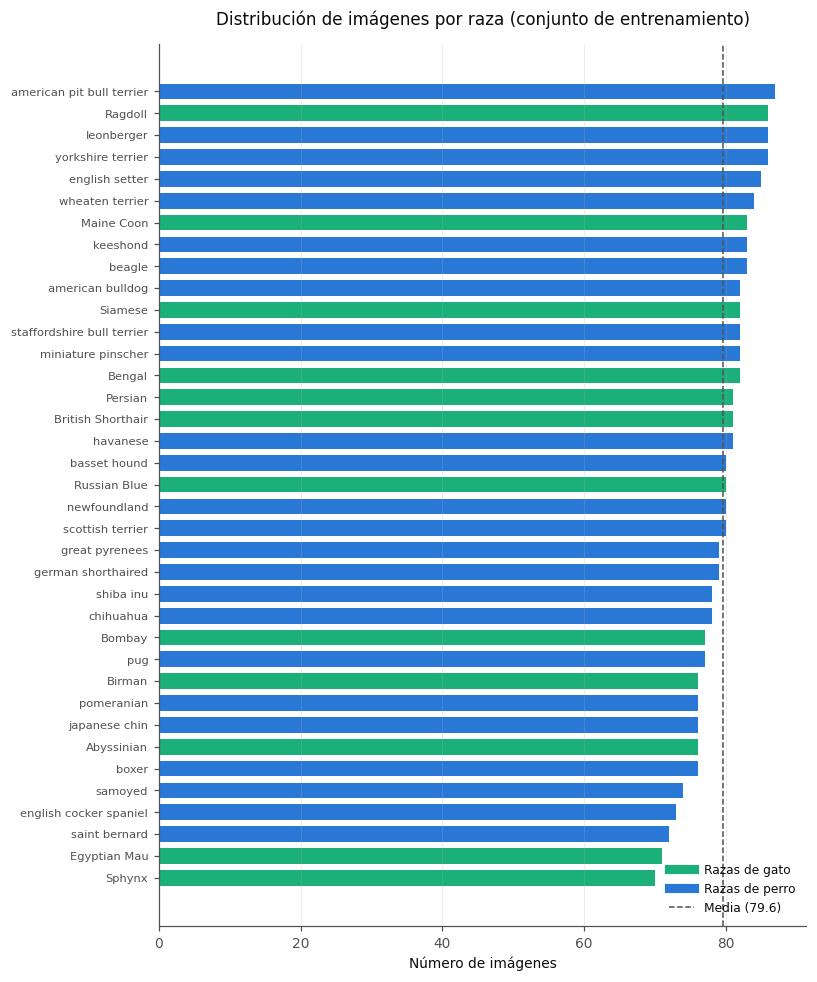

In [ ]:
graficar_distribucion_clases(
    conteos_ent, nombres_clases, ESPECIE_POR_CLASE,
    "Distribución de imágenes por raza (conjunto de entrenamiento)",
)


   Dibujando el balance entre gatos y perros. 
 


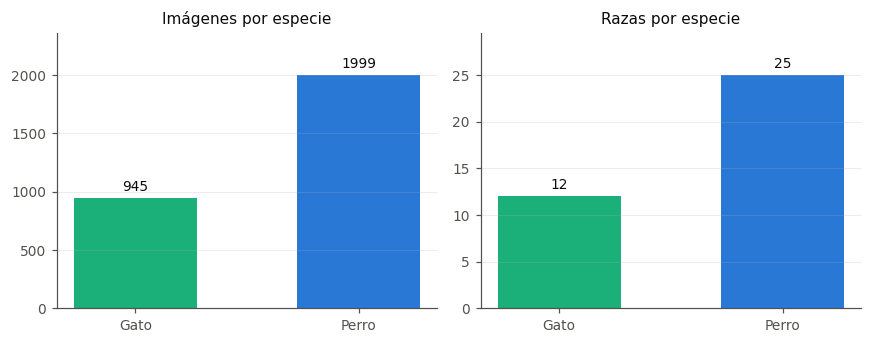

In [ ]:
_imgs_especie, _razas_especie = graficar_balance_especies(conteos_especies_ent, ESPECIE_POR_CLASE)

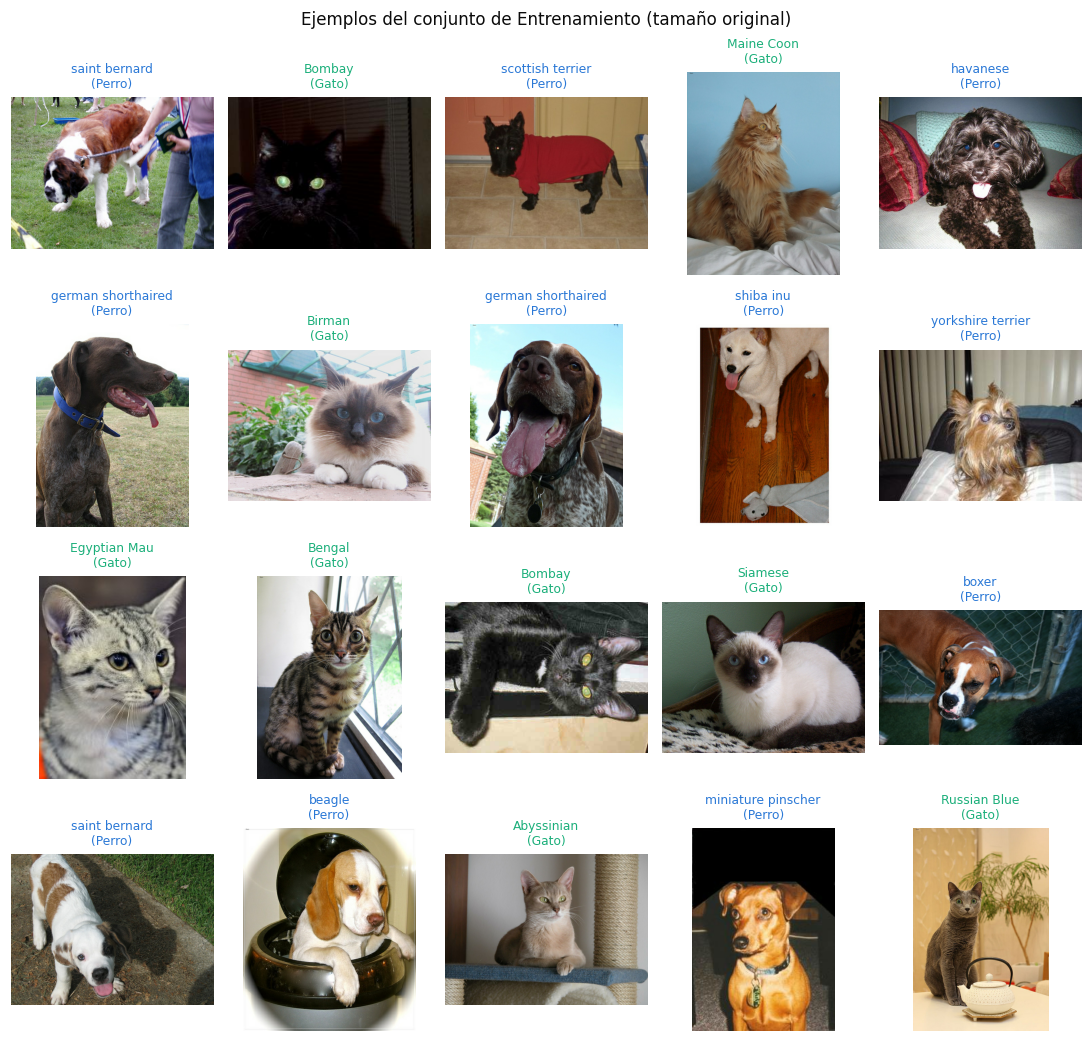

In [ ]:
mostrar_muestras(train_ds_bruto, nombres_clases,"Entrenamiento", filas=4, columnas=5, )

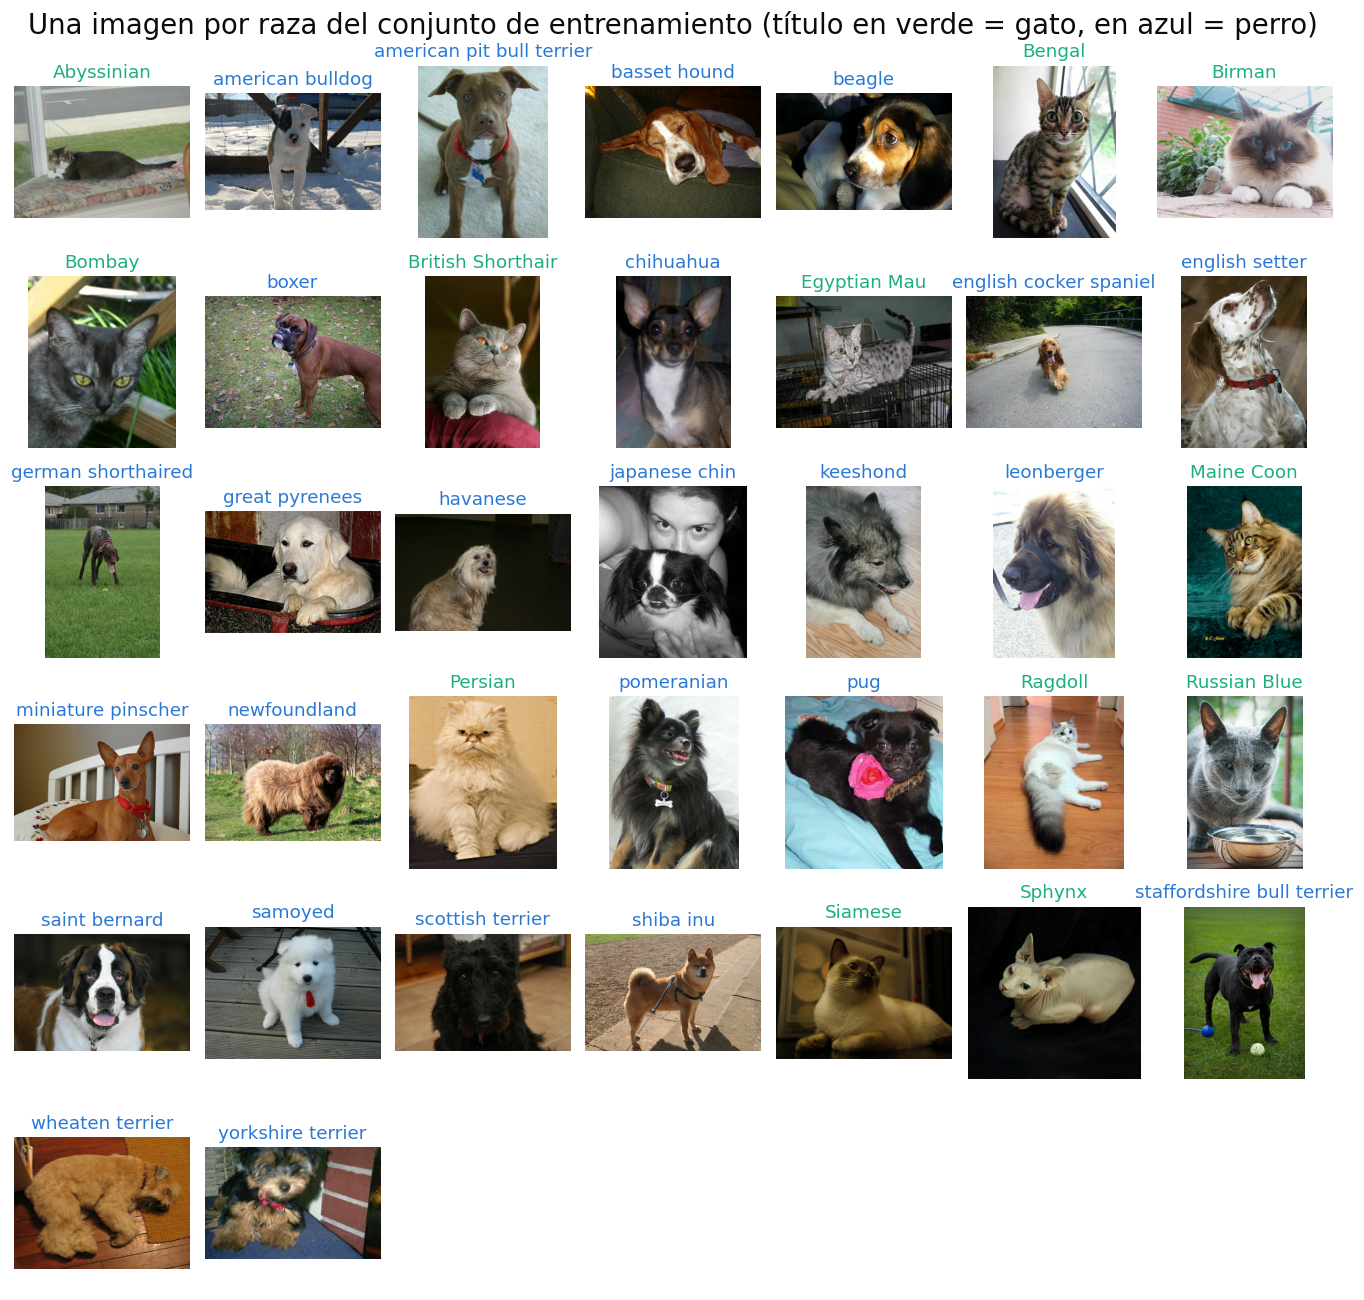

In [ ]:
_representantes = mostrar_una_imagen_por_clase(train_ds_bruto, nombres_clases, "entrenamiento")

### 2.5 Resolución, relación de aspecto e iluminación

Analizando resolución, relación de aspecto y brillo de una muestra de imágenes 📐
Dibujando las estadísticas descriptivas de las imágenes 📈


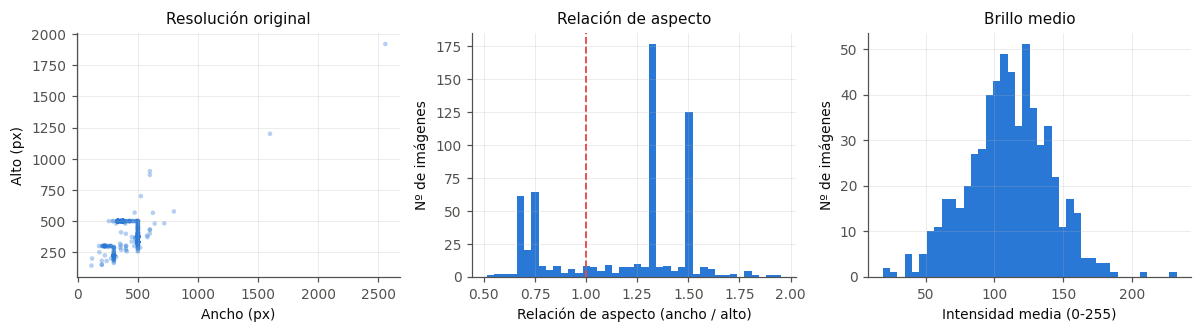

Ancho : min 114  max 2560  mediana 500
Alto  : min 143  max 1920  mediana 375
Aspecto: media 1.18  [0.52, 1.95]
Media RGB del muestreo: [119.6 113.   98.4]


In [ ]:
estadisticas_imagenes = analizar_muestra_imagenes(train_ds_bruto, n_muestras=600)
graficar_estadisticas_imagenes(estadisticas_imagenes)

* El ancho va desde $114$ px hasta $2560$ px, con una mediana de $500$ px. Eso significa que se tiene imágenes muy pequeñas y otras bastante grandes. La mediana de $500$ indica que aproximadamente la mitad de las imágenes tiene un ancho menor o igual a $500$ px y la otra mitad mayor o igual.
* El alto va desde $143$ px hasta $1920$ px, con una mediana de $375$ px. Igual que con el ancho, hay bastante variabilidad. Una imagen “típica” de tu conjunto, tomando las medianas, estaría cerca de:

        500 x 375 px

* La relación de aspecto tiene una media de $1.8$
$\frac{ancho}{alto}$
un valor mayor que $1$ significa que la imagen es más ancha que alta. Por tanto en promedio, tus imágenes son ligeramente horizontales.
*  El rango [$0.52$, $1.95$] indica que tienes bastantes distintas:
    - $0.52$: imagen claramente vertical.
    - $1.00$: imagen cuadrada.
    - $1.18$: ligeramente horizontal.
    - $1.95$: imagen muy horizontal, casi el doble de ancha que alta.

Esta variabilidad justifica la aplicación de un proceso de redimensionamiento antes de introducir las imágenes al modelo

* En cuanto al color, las intensidades medias RGB fueron [$119.8$, $113.0$, $98.4$], mostrando una ligera predominancia de los canales rojo y verde frente al azul.

### 2.6 Conclusiones

| Hallazgo | Consecuencia sobre el diseño |
|---|---|
| $3,312$ imágenes de entrenamiento para $37$ clases ($90$ por clase) | Insuficiente para entrenar desde cero una red profunda: se hace obligatorio el *transfer learning* y una regularización agresiva en los modelos propios. |
| Clases balanceadas a nivel de raza | La *accuracy* es una métrica válida; no se necesitan pesos por clase ni remuestreo. |
| Resoluciones heterogéneas y relaciones de aspecto variables | Es imprescindible **redimensionar** a un tamaño fijo ($160$×$160$). Se acepta la distorsión del aspecto a cambio de conservar el objeto completo.
| Rango de píxeles [$0$, $255$] y brillo muy variable | Es obligatorio **normalizar**; la variabilidad de iluminación justifica el aumento de contraste/brillo en el *data augmentation*. |
| Alta variabilidad intra-clase (pose, escala, fondo, oclusión) | Justifica el *data augmentation* geométrico (volteo, rotación, traslación, zoom). |

## 3. Preprocesamiento

**Redimensionado.** Una capa densa exige un vector de tamaño fijo y una CNN entrenada por lotes exige que
todos los elementos del lote tengan la misma forma, de modo que todas las imágenes se llevan a 160×160×3.


Existen dos estrategias:
* *(a)* escalar directamente, distorsionando la relación de aspecto.
* *(b)* recortar o rellenar (*letterboxing*) para preservarla.

Se elige la primera porque garantiza que el animal completo
permanece en la imagen —el EDA mostró sujetos descentrados y encuadres muy dispares— y porque la CNN puede
aprender a tolerar una distorsión moderada, que además actúa como una forma leve de regularización.

**Normalización.** Los píxeles llegan como enteros en $[0, 255]$. Alimentar una red con esos valores es
problemático: las activaciones iniciales son grandes, los gradientes se desestabilizan y la convergencia se
ralentiza. Las dos normalizaciones utilizadas en este trabajo son:

$$x' = \frac{x}{255} \in [0, 1] \qquad \text{(modelos propios, capa \texttt{Rescaling(1/255)})}$$

$$x' = \frac{x}{127.5} - 1 \in [-1, 1] \qquad \text{(MobileNetV2, su preprocesado original)}$$

Un detalle **crítico** del *transfer learning*: la normalización debe ser exactamente la misma con la que se
entrenó la red preentrenada. MobileNetV2 se entrenó con entradas en $[-1, 1]$; usar $[0, 1]$ degrada el
rendimiento de forma notable aunque el código no dé ningún error.

**Dónde normalizar.** La normalización se implementa como **primera capa del modelo** (`keras.layers.
Rescaling`) y no dentro del *pipeline* `tf.data`. La ventaja es que el modelo guardado queda
*autocontenido*: acepta imágenes en el rango original y no hay riesgo de aplicar en inferencia un
preprocesado distinto del de entrenamiento.

**Del diccionario a la tupla supervisada.** Como el dataset se carga con `as_supervised=False`, cada elemento
es un diccionario con seis campos. La primera operación del *pipeline* selecciona la entrada (`image`) y el
objetivo (`label`, la raza) y descarta el resto, que ya se ha explotado en el análisis: es lo que Keras
espera en `fit()`. La especie no se propaga al *pipeline* de entrenamiento porque **no es el objetivo de la
tarea**.

**Codificación de las etiquetas.** Las etiquetas se mantienen como enteros ($0..36$) y se emplea la pérdida
`sparse_categorical_crossentropy`, matemáticamente equivalente a `categorical_crossentropy` sobre vectores
*one-hot* pero sin materializar una matriz de $N \times 37$ valores.

### 3.1 Funciones de preprocesamiento

In [ ]:
# =====================================================================
# 5.1. Funciones de preprocesado
# =====================================================================

def preparar_ejemplo(ejemplo, tam=TAM_IMG):
    """Convierte el diccionario del dataset en la tupla (imagen, raza).

    Es el punto en el que se pasa del formato completo (as_supervised=False) al
    formato supervisado que espera Keras: se selecciona `image` como entrada y
    `label` (la raza) como objetivo, y se descartan el resto de anotaciones, que
    ya se han aprovechado en el análisis.

    La imagen se lleva a tam x tam y se mantiene en uint8 para que la caché en
    memoria ocupe cuatro veces menos que en float32; la conversión a float se
    realiza después del batch.
    """
    #Necesario porque una red neuronal necesita que todas las imágenes de un lote tengan las mismas dimensiones
    imagen = tf.image.resize(ejemplo["image"], (tam, tam), method="bilinear") #Redimensiona todas las imágenes al mismo tamaño
    #tf.image.resize devuelve no. decimales.
    imagen = tf.cast(tf.round(imagen), tf.uint8) #redondeamos los valores y después lo convierte a tipo entero
    # uint8 utiliza 1 byte por valor mientras que float32 utiliza 4 bytes por valor  (4 veces más memoria)
    return imagen, ejemplo["label"] #Retorna el tensor , raza


def preparar_ejemplo_con_especie(ejemplo, tam=TAM_IMG):
    """Variante multitarea: (imagen, {"raza": ..., "especie": ...}).
    Esto permitiría construir un modelo con dos salidas
    imagen -> CNN -> capas (clasificación de raza, clasificación de especie)
    """

    imagen = tf.image.resize(ejemplo["image"], (tam, tam), method="bilinear")
    imagen = tf.cast(tf.round(imagen), tf.uint8)
    return imagen, {"raza": ejemplo["label"], "especie": ejemplo["species"]} #Es para un modelo multitarea


def a_flotante(imagenes, etiquetas):
    """Convierte un lote de imágenes uint8 a float32 conservando el rango [0, 255].
    Una normalización sería algo como:
    imagenes = tf.cast(imagenes, tf.float32) / 255.0
    o se puede hacer posteriormente dentro del propio modelo, mediante una capa.
    layers.Rescaling(1./255)
    """
    return tf.cast(imagenes, tf.float32), etiquetas


def preparar_dataset(ds, tam_lote=TAM_LOTE, entrenamiento=False, cachear=True,
                     tam_buffer=1024, semilla=SEMILLA, funcion_preparacion=None):
    """Construye el pipeline tf.data completo para una partición.

    Orden de las operaciones (relevante para el rendimiento y la corrección):
        map(diccionario -> (imagen, raza)) -> cache -> shuffle -> batch
        -> map(float32) -> prefetch
    El barajado solo se aplica a entrenamiento: en validación y test el orden debe
    ser determinista para poder alinear predicciones con etiquetas.
    """
    print(f"Construyendo el pipeline tf.data (entrenamiento={entrenamiento}): "
          f"redimensionado, caché, barajado, lotes y prefetch 🔧")
    #Si no se introduce una función de preparación, utiliza preparar ejemplo
    funcion_preparacion = funcion_preparacion or preparar_ejemplo
    ds = ds.map(funcion_preparacion, num_parallel_calls=AUTOTUNE) #(imagen_redimensionada, etiqueta_raza)
    """map() aplica una función a cada elemento del dataset.
    num_parallel_calls=AUTOTUNE permite que TensorFlow decida automáticamente cuántos elementos procesar paralelamente."""
    if cachear:
        ds = ds.cache()
        """cache() guarda los resultados después de la primera pasada.
        sin cache() y en la segunda época TensorFlow tendría que repetir el redimensionamiento."""
    if entrenamiento: #comprueba si el dataset corresponde al conjunto de entrenamiento.
        ds = ds.shuffle(tam_buffer, seed=semilla, reshuffle_each_iteration=True)
        #shuffle() mezcla los ejemplos.
    """ Esto es importante en entrenamiento porque no quieres que el modelo aprenda accidentalmente patrones
    relacionados con el orden de los datos.
    tam_buffer=1024 significa que TensorFlow mantiene un buffer de hasta 1024 ejemplos para realizar la mezcla.
    Cuanto mayor sea el buffer, mejor suele ser el barajado, aunque también requiere más memoria.

    seed=semilla permite reproducibilidad.

    reshuffle_each_iteration=True -> indica que se vuelva a barajar el conjunto en cada época. (deseable solo en entrenamiento)
    """
    ds = ds.batch(tam_lote)
    """ Agrupa las imagenes en lotes. En lugar de enviar al modelo una imagen cada vez,
    se envían en grupos lote 1 -> 32 imágenes.
    La forma general es (batch, alto, ancho, canales) """
    ds = ds.map(a_flotante, num_parallel_calls=AUTOTUNE)
    """
    resize -> uint8 -> cache ->shuffle -> batch -> float32
    Si hubieras convertido a float32 antes del cache(), el caché utilizaría aproximadamente cuatro veces más memoria.

    prefetch() sirve para mejorar el rendimiento durante entrenamiento.
    La idea es que TensorFlow puede preparar el siguiente lote mientras la GPU está trabajando con el lote actual.

    con prefetch() -> GPU procesa lote 1 mientras CPU prepara lote 2
    sin pretech() -> CPU prepara lote 1 GPU espera
    AUTOTUNE deja que TensorFlow determine automáticamente cuánto preprocesamiento adelantar.
    """
    return ds.prefetch(AUTOTUNE)

## 4 Data augmentation

El *data augmentation* genera, en cada época, variantes aleatorias de cada imagen de entrenamiento. Su
fundamento es la **invarianza**: la etiqueta "beagle" no cambia si el perro aparece reflejado, girado unos
grados, ligeramente desplazado o con otra iluminación. Al mostrar esas variantes, se enseña explícitamente a
la red a ignorar factores irrelevantes y se amplía artificialmente el soporte de la distribución de
entrenamiento. Formalmente actúa como un **regularizador**: reduce la varianza del estimador y, por tanto, la
brecha entre el error de entrenamiento y el de validación.

Transformaciones utilizadas y su justificación:

| Transformación | Parámetro | Justificación |
|---|---|---|
| `RandomFlip("horizontal")` | — | Un animal reflejado sigue siendo de la misma raza. **No** se usa volteo vertical: una mascota boca abajo no aparece en el dominio. |
| `RandomRotation` | ±8 % (≈ ±29°) | Cubre las inclinaciones típicas de una fotografía de mano. |
| `RandomZoom` | ±10 % | Simula variaciones de distancia sin llegar a recortar al animal. |
| `RandomTranslation` | ±8 % | El EDA mostró sujetos descentrados. |
| `RandomContrast` | ±15 % | Compensa la fuerte variabilidad de iluminación observada en el histograma de brillo. |


**Dos decisiones de implementación:**

1. **Las capas de aumento se insertan dentro del modelo**, no en el *pipeline* `tf.data`. Keras las ejecuta
   **solo en modo entrenamiento** (`training=True`) y las desactiva automáticamente en `evaluate()` y
   `predict()`, lo que elimina por completo el riesgo —muy habitual— de evaluar con imágenes aumentadas.
   Además, así se ejecutan en la GPU junto con el resto del grafo.
2. **El aumento se aplica antes del reescalado**, sobre el rango original $[0, 255]$, que es el que esperan
   por defecto las capas de contraste de Keras.

Es importante recordar que el *data augmentation* se aplica **únicamente al conjunto de entrenamiento**;
validación y test deben permanecer intactos para que sus métricas estimen el rendimiento real.

### 4.1 Funciones de data augmentation

In [ ]:
def crear_aumentador(semilla=SEMILLA, nombre="aumentacion"):
    """Devuelve el bloque de capas de aumento de datos (activo solo en entrenamiento)."""
    print("Creando el bloque de data augmentation: volteo, rotación, zoom, traslación y contraste 🔄")
    return keras.Sequential(
        [
            keras.layers.RandomFlip("horizontal", seed=semilla),
            keras.layers.RandomRotation(0.08, fill_mode="reflect", seed=semilla),
            keras.layers.RandomZoom(0.10, fill_mode="reflect", seed=semilla),
            keras.layers.RandomTranslation(0.08, 0.08, fill_mode="reflect", seed=semilla),
            keras.layers.RandomContrast(0.15, seed=semilla),
        ],
        name=nombre,
    )


def visualizar_aumentacion(ds, aumentador, n_clases=5, n_variantes=4, semilla=SEMILLA):
    """Muestra varias clases distintas con su imagen original y versiones aumentadas."""
    print(f"Mostrando data augmentation sobre {n_clases} clases diferentes 🎨")

    ejemplos_seleccionados = []
    clases_vistas = set()

    ds_barajado = ds.shuffle(1024, seed=semilla, reshuffle_each_iteration=False)

    for ejemplo in ds_barajado:
        etiqueta = int(ejemplo["label"].numpy())

        if etiqueta not in clases_vistas:
            ejemplos_seleccionados.append(ejemplo)
            clases_vistas.add(etiqueta)

        if len(ejemplos_seleccionados) == n_clases:
            break

    n_columnas = n_variantes + 1
    fig, ejes = plt.subplots(
        len(ejemplos_seleccionados),
        n_columnas,
        figsize=(1.8 * n_columnas, 2.2 * len(ejemplos_seleccionados))
    )

    ejes = np.atleast_2d(ejes)

    for fila, ejemplo in enumerate(ejemplos_seleccionados):
        imagen = tf.cast(
            tf.image.resize(ejemplo["image"], (TAM_IMG, TAM_IMG)),
            tf.float32
        )

        etiqueta = int(ejemplo["label"].numpy())
        nombre_clase = nombres_clases[etiqueta].replace("_", " ")
        lote = tf.expand_dims(imagen, axis=0)

        ejes[fila, 0].imshow(np.clip(imagen.numpy(), 0, 255).astype("uint8"))
        ejes[fila, 0].set_title(f"Original\n{nombre_clase}", fontsize=8, color=C_SERIE_2)
        ejes[fila, 0].axis("off")

        for columna in range(1, n_columnas):
            aumentada = aumentador(lote, training=True)[0].numpy()
            ejes[fila, columna].imshow(np.clip(aumentada, 0, 255).astype("uint8"))
            ejes[fila, columna].set_title(f"Aumentada {columna}", fontsize=8, color=C_SUAVE)
            ejes[fila, columna].axis("off")

    fig.suptitle(f"Data augmentation en {len(ejemplos_seleccionados)} clases diferentes", fontsize=11)
    fig.tight_layout()
    plt.show()

### 4.2 Construcción de los pipelines

In [ ]:
# --- Ejecución estructurada: pipelines definitivos -------------------
train_ds = preparar_dataset(train_ds_bruto, entrenamiento=True, cachear=True)
val_ds    = preparar_dataset(val_ds_bruto, entrenamiento=False, cachear=True)
# El test no se cachea: se recorre pocas veces y evita ~280 MB de memoria.
test_ds        = preparar_dataset(test_ds_bruto, entrenamiento=False, cachear=False)


Construyendo el pipeline tf.data (entrenamiento=True): redimensionado, caché, barajado, lotes y prefetch 🔧
Construyendo el pipeline tf.data (entrenamiento=False): redimensionado, caché, barajado, lotes y prefetch 🔧
Construyendo el pipeline tf.data (entrenamiento=False): redimensionado, caché, barajado, lotes y prefetch 🔧


In [ ]:
_lote_imgs, _lote_etqs = next(iter(train_ds))
print("Forma del lote de imágenes:", _lote_imgs.shape, _lote_imgs.dtype)
print("Forma del lote de etiquetas:", _lote_etqs.shape, _lote_etqs.dtype)
print(f"Rango de valores: [{float(tf.reduce_min(_lote_imgs)):.1f}, "
      f"{float(tf.reduce_max(_lote_imgs)):.1f}]")
print(f"Lotes por época: entrenamiento={int(train_ds.cardinality())}, "
      f"validación={int(val_ds.cardinality())}, test={int(test_ds.cardinality())}")

Forma del lote de imágenes: (32, 160, 160, 3) <dtype: 'float32'>
Forma del lote de etiquetas: (32,) <dtype: 'int64'>
Rango de valores: [0.0, 255.0]
Lotes por época: entrenamiento=92, validación=23, test=115


### 4.3 Comprobación visaul del data augmentation

Antes de entrenar conviene verificar que las transformaciones son **realistas**: una imagen aumentada debe
seguir siendo una fotografía plausible de la misma raza. Un aumento demasiado agresivo introduce ruido de
etiqueta y degrada el aprendizaje en lugar de mejorarlo.

Creando el bloque de data augmentation: volteo, rotación, zoom, traslación y contraste 🔄
Mostrando data augmentation sobre 6 clases diferentes 🎨


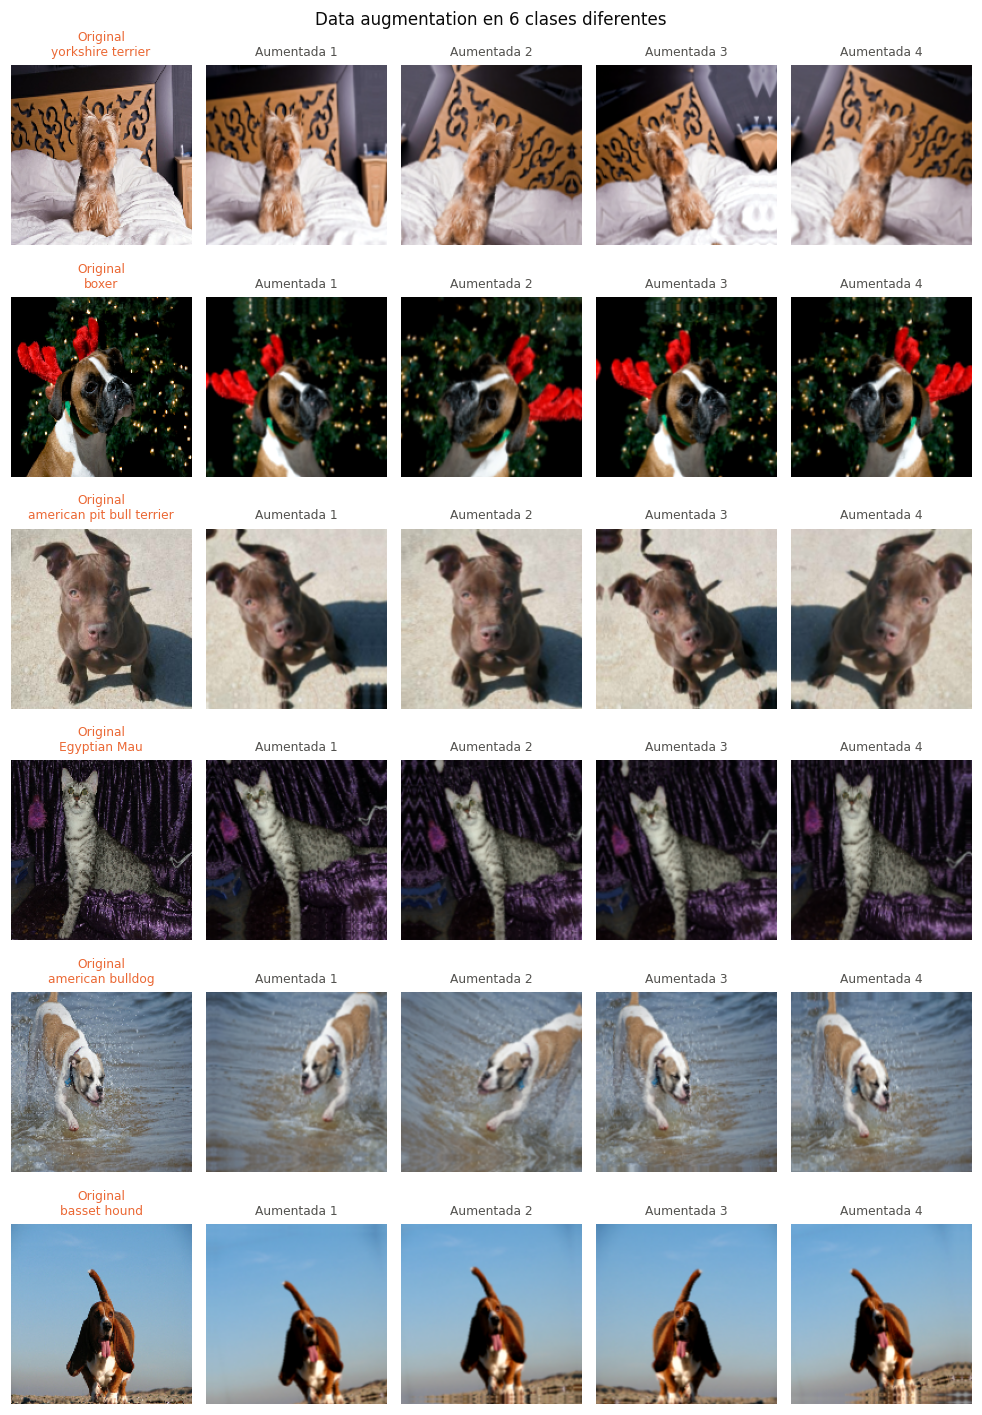

In [ ]:
aumentador_demo = crear_aumentador()
visualizar_aumentacion(train_ds_bruto, aumentador_demo,  n_clases=6, n_variantes=4)


## 5. Fundamentos  teóricos de las CNN

#### 5.1 Del perceptrón multicapa a la convolución

Una capa **densa** (*fully connected*) conecta cada neurona con **todas** las entradas:

$$\mathbf{h} = \sigma(W\mathbf{x} + \mathbf{b})$$

Aplicada directamente a una imagen de 160×160×3, la entrada debe aplanarse en un vector de
$160 \times 160 \times 3 = 76\,800$ componentes. Una primera capa oculta de solo 512 neuronas requiere ya
$76\,800 \times 512 \approx 39{,}3$ millones de parámetros. Esto plantea tres problemas graves:

1. **Coste paramétrico.** 39 millones de parámetros para $3,312$ imágenes de entrenamiento: el modelo puede
   memorizar el conjunto por completo, con *overfitting* garantizado.
2. **Pérdida de la estructura espacial.** Al aplanar, dos píxeles vecinos dejan de ser vecinos; la red debe
   reaprender la noción de proximidad a partir de los datos.
3. **Ausencia de invarianza a la traslación.** Un hocico en la esquina superior izquierda y el mismo hocico en
   el centro activan pesos completamente distintos, por lo que la red tendría que aprender cada patrón tantas
   veces como posiciones existan.

La **convolución** resuelve los tres problemas mediante dos principios de diseño:
* **conectividad local** (cada neurona solo mira una vecindad pequeña)
* **pesos compartidos** (el mismo detector se aplica en todas
las posiciones).

### 5.2 Operación de convolución.

Para una entrada $x$ con $C$ canales y un núcleo (*kernel*) $w$ de tamaño $K \times K$, el mapa de
activación $k$-ésimo se calcula como:

$$y_{i,j,k} \;=\; b_k \;+\; \sum_{u=0}^{K-1}\sum_{v=0}^{K-1}\sum_{c=0}^{C-1} w_{u,v,c,k}\; x_{i+u,\; j+v,\; c}$$

Cada núcleo es un **detector de patrones** que se desliza por toda la imagen. Los pesos no se diseñan a mano:
se aprenden por descenso de gradiente. Empíricamente, los núcleos de las primeras capas convergen hacia
detectores de bordes y de color, y los de las capas profundas hacia partes de objeto (ojos, orejas,
texturas de pelaje), que es exactamente la jerarquía que necesita este problema.

**Número de parámetros de una capa convolucional:**

$$P = (K \times K \times C_{\text{ent}} + 1) \times C_{\text{sal}}$$

Obsérvese que **no depende del tamaño de la imagen**. Una capa `Conv2D(32, 3x3)` sobre una entrada RGB tiene
$(3 \cdot 3 \cdot 3 + 1)\cdot 32 = 896$ parámetros, frente a los millones de una densa equivalente.

**Tamaño de salida.** Con relleno (*padding*) $P$ y paso (*stride*) $S$:

$$O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1$$

* `padding="valid"` ($P=0$): la salida se encoge en cada capa y se pierde información del borde.
* `padding="same"`: se rellena con ceros para que $O = I$ cuando $S = 1$.

**Campo receptivo.** Es la región de la imagen original que influye sobre una activación. Apilar dos
convoluciones $3\times3$ produce un campo receptivo de $5\times5$ con menos parámetros que una única
convolución $5\times5$ ($2 \cdot 9 = 18$ frente a $25$ pesos por canal) y con una no linealidad adicional
intercalada. Este es el motivo por el que las arquitecturas modernas usan casi exclusivamente núcleos
$3\times3$ apilados.

### 5.3 Pooling y global average pooling

El **max-pooling** divide cada mapa de activación en ventanas (típicamente $2\times2$) y conserva el máximo:

$$y_{i,j} = \max_{(u,v)\in \mathcal{W}_{i,j}} x_{u,v}$$

Cumple tres funciones: reduce la resolución espacial a la mitad (y con ella el coste computacional),
aumenta el campo receptivo efectivo de las capas siguientes y aporta una **invarianza local a pequeños
desplazamientos**, ya que el máximo de una ventana no cambia si el patrón se mueve un píxel. No tiene
parámetros entrenables.

El **global average pooling (GAP)** promedia cada mapa de activación completo, transformando un tensor
$H \times W \times C$ en un vector de longitud $C$:

$$g_c = \frac{1}{H \cdot W}\sum_{i,j} x_{i,j,c}$$

Es la alternativa moderna a `Flatten` antes del clasificador. Con mapas finales de $5\times5\times256$,
`Flatten` produce un vector de 6 400 componentes (y ~1,6 M de parámetros si le sigue una densa de 256),
mientras que GAP produce uno de 256 (~65 K parámetros): **una reducción de 25×** que actúa como un fuerte
regularizador estructural. Por este motivo GAP es la elección en los modelos 3, 4 y 5.

### 5.4 Funciones de activación

Sin no linealidades, una pila de capas lineales colapsa en una única transformación lineal. Las utilizadas
aquí son:

**ReLU** — $\;f(z) = \max(0, z)$. Es la activación por defecto en capas ocultas: su gradiente es exactamente
1 para $z > 0$, lo que evita el desvanecimiento del gradiente que sufren la sigmoide y la tangente
hiperbólica en redes profundas, y su cálculo es trivial. Su inconveniente es la *dying ReLU*: una neurona que
queda siempre en la zona negativa deja de recibir gradiente y no vuelve a aprender; la *batch normalization*
y una tasa de aprendizaje moderada lo mitigan.

**Softmax** — capa de salida en clasificación multiclase:

$$p_k = \frac{e^{z_k}}{\sum_{j=1}^{37} e^{z_j}}$$

Convierte los *logits* en una distribución de probabilidad sobre las 37 razas ($p_k>0$, $\sum_k p_k = 1$).
Se usa `softmax` explícito en la última capa, de modo que `predict()` devuelve directamente probabilidades
interpretables.

### 5.5 Batch Normalization

Durante el entrenamiento, la distribución de las entradas de cada capa cambia continuamente porque las capas
anteriores actualizan sus pesos (*internal covariate shift*). La *batch normalization* (Ioffe y Szegedy,
2015) normaliza cada canal usando la media y la varianza del mini-lote y aplica después una transformación
afín aprendible:

$$\hat{x} = \frac{x - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \epsilon}}, \qquad y = \gamma \hat{x} + \beta$$

Los parámetros $\gamma$ y $\beta$ permiten a la red recuperar la escala original si le conviene. Sus efectos
prácticos son: permite tasas de aprendizaje mayores, acelera la convergencia, reduce la sensibilidad a la
inicialización y aporta una ligera regularización (el ruido de estimar $\mu$ y $\sigma$ por lote).

**Comportamiento dual, clave para el *fine-tuning*.** En entrenamiento usa las estadísticas del lote; en
inferencia usa medias móviles acumuladas. Por eso, al descongelar un modelo preentrenado, las capas de
*batch normalization* deben **mantenerse congeladas**: si se dejan actualizar con lotes pequeños del nuevo
dominio, destruyen las estadísticas aprendidas sobre ImageNet y el rendimiento se desploma

### 5.6 Regularización

**Dropout.** En cada paso de entrenamiento desactiva cada neurona con probabilidad $p$:

$$\tilde{h}_i = \frac{h_i}{1-p}\cdot m_i, \qquad m_i \sim \text{Bernoulli}(1-p)$$

Impide la **coadaptación** entre neuronas —ninguna puede depender de la presencia de otra— y equivale
aproximadamente a promediar un conjunto exponencial de subredes. Se desactiva automáticamente en inferencia
(de ahí el reescalado por $1/(1-p)$, que mantiene la esperanza de la activación). Se aplica con $p$ creciente
con la profundidad, y con el valor mayor justo antes del clasificador, que es donde se concentran los
parámetros.

**Regularización L2 (*weight decay*).** Añade a la pérdida una penalización sobre la magnitud de los pesos:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{datos}} + \lambda \sum_i w_i^2$$

Favorece soluciones con pesos pequeños y por tanto funciones más suaves, menos propensas a ajustar el ruido.

**Early stopping.** Detiene el entrenamiento cuando la pérdida de validación deja de mejorar durante un
número de épocas (*patience*) y restaura los mejores pesos. Es la forma más directa de regularización: limita
la capacidad efectiva del modelo controlando el tiempo de optimización.

**Data augmentation.** Amplía artificialmente el conjunto de entrenamiento.

**Reducción arquitectónica.** El uso de GAP en lugar de `Flatten` elimina millones de parámetros y es, en la
práctica, una de las regularizaciones más efectivas.

### 5.6 Función de pérdida y optimización

**Entropía cruzada categórica.** Para una muestra con clase verdadera $y$ y probabilidades predichas $p$:

$$\mathcal{L} = -\sum_{k} \mathbb{1}[k = y]\,\log p_k = -\log p_y$$

Penaliza logarítmicamente la probabilidad asignada a la clase correcta: un error confiado (probabilidad
próxima a 0 en la clase verdadera) genera una pérdida muy grande, lo que empuja al modelo a calibrar su
confianza. La variante *sparse* acepta la etiqueta como entero, evitando materializar los vectores *one-hot*.

**Descenso de gradiente estocástico y Adam.** La actualización básica es
$\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}$. **Adam** (Kingma y Ba, 2015) añade momento de
primer y segundo orden con corrección de sesgo:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \qquad
\theta_{t+1} = \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Al normalizar cada coordenada por la raíz de la media de sus gradientes al cuadrado, Adam adapta el paso
efectivo por parámetro, lo que lo hace robusto sin apenas ajuste manual. Es el optimizador empleado en todos
los modelos, con $\eta = 10^{-3}$ al entrenar desde cero, $\eta = 10^{-3}$ para la cabeza en *transfer
learning* y $\eta = 10^{-5}$ en *fine-tuning*.

**Tasa de aprendizaje.** Es el hiperparámetro más sensible: demasiado alta provoca divergencia u oscilación;
demasiado baja, convergencia lenta o estancamiento en malos mínimos. Se emplea `ReduceLROnPlateau`, que la
divide por 2 cuando la pérdida de validación se estanca, permitiendo un ajuste fino en la fase final.

### 5.7 Transfer Learning y Fine-tuning


Una CNN entrenada sobre ImageNet (1,28 M de imágenes, 1 000 clases) ha aprendido en sus capas convolucionales
un extractor de características **genérico**: bordes, texturas, formas y partes de objeto que son útiles
mucho más allá de las clases con las que se entrenó. Además, ImageNet contiene ~120 razas de perro, de modo
que sus representaciones son especialmente pertinentes para este problema.

**Estrategia 1 — extracción de características (Modelo 4).** Se congela el modelo base
(`base.trainable = False`), se sustituye su clasificador por una cabeza nueva y solo se entrena esta última.
Se entrenan decenas de miles de parámetros en lugar de millones, el riesgo de *overfitting* es bajo y el
entrenamiento resulta muy rápido.

**Estrategia 2 — *fine-tuning* (Modelo 5).** Partiendo del modelo anterior ya entrenado, se descongelan las
**últimas** capas convolucionales y se reentrena todo el conjunto con una tasa de aprendizaje muy pequeña.
Esto permite **especializar** las características de alto nivel —las más específicas del dominio— hacia las
razas concretas del problema. Tres reglas son imprescindibles:

1. **Entrenar primero la cabeza.** Con una cabeza inicializada al azar, los gradientes iniciales son enormes
   y destruirían los pesos preentrenados en las primeras iteraciones.
2. **Tasa de aprendizaje muy baja** ($10^{-5}$): se trata de refinar, no de reaprender.
3. **Mantener congeladas las capas de *batch normalization***

**MobileNetV2 como modelo base.** Se elige por su excelente relación precisión/coste: ~2,3 M de parámetros
frente a los ~23 M de ResNet50. Sus tres ideas son las **convoluciones separables en profundidad**
(*depthwise separable*), que factorizan una convolución estándar en una espacial por canal más una $1\times1$
de mezcla, reduciendo el coste en un orden de magnitud; los **residuos invertidos**, que expanden los canales
dentro del bloque y los comprimen a la salida; y los **cuellos de botella lineales**, que evitan la ReLU
final del bloque para no destruir información en espacios de baja dimensión. Acepta entradas de 160×160, el
tamaño usado en este trabajo, y espera valores normalizados en $[-1, 1]$.


### 5.8 Protocolo de entrenamiento y callbacks.


Los *callbacks* de Keras permiten intervenir en el bucle de entrenamiento. Se usan tres:

| *Callback* | Configuración | Propósito |
|---|---|---|
| `ModelCheckpoint` | `monitor="val_accuracy"`, `save_best_only=True` | Persiste **el mejor modelo según validación**, no el de la última época. Permite evaluar y analizar errores después sin reentrenar. |
| `EarlyStopping` | `monitor="val_loss"`, `patience`, `restore_best_weights=True` | Detiene el entrenamiento cuando el modelo empieza a sobreajustar y evita gastar cómputo. |
| `ReduceLROnPlateau` | `factor=0.5`, `patience` menor que la de *early stopping* | Refina la convergencia reduciendo la tasa de aprendizaje ante estancamientos. |

Se monitoriza `val_accuracy` para el punto de control (es la métrica objetivo de la actividad) y `val_loss`
para la parada temprana, porque la pérdida es una señal más sensible y detecta el inicio del sobreajuste
antes que la *accuracy*: es habitual que `val_loss` empiece a crecer mientras `val_accuracy` aún se mantiene
estable. La paciencia de `ReduceLROnPlateau` se fija estrictamente por debajo de la de `EarlyStopping` para
que el modelo tenga oportunidad de aprovechar la tasa reducida antes de que el entrenamiento se detenga.

#### 5.8.1 Funciones

In [ ]:
# =====================================================================
# 7.1. Compilación y callbacks
# =====================================================================

def compilar_modelo(modelo, tasa_aprendizaje=1e-3, optimizador="adam"):
    """Compila un modelo con la configuración común a todos los experimentos.
    La tasa de aprendizaje controla qué tan grandes son los cambios que hace el modelo en sus pesos durante el entrenamiento.
    Una tasa demasiado alta puede hacer que el modelo no converja; una demasiado baja puede volver el entrenamiento muy lento.
    """
    print(f"Compilando el modelo con su optimizador {optimizador}, su función de pérdida y sus métricas ⚙")
    if optimizador == "adam":
        opt = keras.optimizers.Adam(learning_rate=tasa_aprendizaje)
    elif optimizador == "sgd":
        opt = keras.optimizers.SGD(learning_rate=tasa_aprendizaje, momentum=0.9, nesterov=True)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizador}")

    modelo.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy", #Es apropiada para clasificación multiclase cuando las etiquetas son enteros.
        metrics=[
            "accuracy", #mide el porcentaje de veces que la clase con mayor probabilidad coincide con la clase real.
            keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3"), #calcula el Top-3 accuracy.
        ],
    )
    return modelo


def crear_callbacks(ruta_modelo, paciencia_parada=10, paciencia_lr=4, factor_lr=0.5):
    """Punto de control del mejor modelo, parada temprana y reducción de la tasa de aprendizaje.
    Los callbacks son funciones que Keras ejecuta automáticamente durante el entrenamiento para controlar
    lo que ocurre entre épocas.

    ModelCheckpoint:    Este callback guarda el mejor modelo durante el entrenamiento.

    monitor="val_accuracy"   ->   significa que observa el accuracy de validación.
    mode="max"   ->   significa que un valor mayor es mejor.
    save_best_only=True  ->   evita guardar un modelo en cada época; solo guarda cuando hay mejora.


    EarlyStopping:  Sirve para detener el entrenamiento si el modelo deja de mejorar.

    monitor="val_loss"          -> Observa la pérdida del conjunto de validación.
    patience                    ->   El entrenamiento se detendrá cuando pasen n épocas sin mejorar val_loss
    Esto ayuda a evitar entrenar inútilmente y también reduce el riesgo de sobreajuste.
    restore_best_weights=True   ->   hace que, al terminar, el modelo recupere automáticamente los pesos correspondientes
    a la mejor val_loss.
    Esto es importante porque el modelo de la última época no necesariamente es el mejor.


    ReduceLROnPlateau:  Este callback reduce la tasa de aprendizaje cuando el modelo se estanca.

    La idea es que al principio el modelo pueda aprender con pasos relativamente grandes,
    pero cuando se acerque a una buena solución haga ajustes más pequeños.

    min_lr=1e-7 impide que la tasa se reduzca indefinidamente.

    """
    print("Creando los callbacks: checkpoint del mejor modelo, early stopping y reducción de la tasa de aprendizaje 🔔")
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(ruta_modelo),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=paciencia_parada,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=factor_lr,
            patience=paciencia_lr,
            min_lr=1e-7,
            verbose=1,
        ),
    ]


def contar_parametros(modelo):
    """Devuelve (parámetros totales, parámetros entrenables)."""
    print("Contando los parámetros totales y entrenables del modelo 🧮")
    totales = int(modelo.count_params())
    entrenables = int(sum(int(np.prod(w.shape)) for w in modelo.trainable_weights))
    return totales, entrenables

### 5.9 Infraestructura experimental

Para que los cinco modelos sean **comparables**, todos deben entrenarse y evaluarse exactamente con el mismo
protocolo. Esta sección define, de una sola vez, las funciones que implementan ese protocolo:

* **Compilación** con la misma pérdida y las mismas métricas.
* **Callbacks** idénticos (punto de control, parada temprana, reducción de la tasa de aprendizaje).
* **Entrenamiento con persistencia**: `entrenar_o_cargar()` guarda el mejor modelo y su historial y, si ya
  existen en disco, los carga en lugar de reentrenar. Es lo que permite reejecutar todo el análisis sin GPU.
* **Evaluación y diagnóstico**: curvas, brecha entrenamiento-validación, métricas y predicciones.
* **Registro de resultados** en una estructura común, `RESULTADOS`, que alimenta la comparativa de la
  sección 13 y garantiza la trazabilidad entre cada modelo, sus hiperparámetros y sus métricas.

Además de `accuracy` se registra la **top-3 accuracy**: en un problema de grano fino con $37$ clases informa de
si los errores son "casi aciertos" (la clase correcta queda entre las tres más probables) o fallos completos.

### 6 Entrenamiento con persistencia de los modelos.

Esta es la función que materializa el requisito del enunciado de **no reentrenar innecesariamente**: guarda
el mejor punto de control según validación y su historial, y en ejecuciones posteriores los recupera de
disco.

In [ ]:
# =====================================================================
# 7.2. Entrenamiento con persistencia
# =====================================================================

def _ruta_modelo(nombre):
    return DIR_MODELOS / f"{nombre}.keras"


def _ruta_historial(nombre):
    return DIR_MODELOS / f"{nombre}_historial.json"


def guardar_historial(nombre, historia, duracion_s, hiperparametros):
    """Persiste el historial de entrenamiento y los hiperparámetros en formato JSON."""
    print("Guardando en JSON el historial de entrenamiento y los hiperparámetros 💾")
    registro = {
        "historia": {k: [float(v) for v in vals] for k, vals in historia.items()},
        "epocas_ejecutadas": len(historia["loss"]),
        "tiempo_entrenamiento_s": float(duracion_s),
        "hiperparametros": hiperparametros,
    }
    _ruta_historial(nombre).write_text(json.dumps(registro, indent=2), encoding="utf-8")
    return registro


def entrenar_o_cargar(nombre, funcion_constructora, train_ds, val_ds,
                      epocas, paciencia_parada=10, paciencia_lr=4,
                      hiperparametros=None, forzar_reentrenamiento=False, verbose=1):
    """Entrena un modelo o lo recupera de disco si ya fue entrenado.

    Parámetros
    ----------
    nombre : identificador usado para los ficheros `modelos/<nombre>.keras` y
             `modelos/<nombre>_historial.json`.
    funcion_constructora : función sin argumentos que devuelve el modelo ya compilado.

    Devuelve (modelo, registro_historial). El modelo devuelto es siempre el MEJOR
    punto de control según `val_accuracy`, nunca el de la última época.
    """
    print(f"Entrenando el modelo '{nombre}', o recuperándolo del disco si ya fue entrenado 🚀")
    ruta_modelo, ruta_hist = _ruta_modelo(nombre), _ruta_historial(nombre)

    if ruta_modelo.exists() and ruta_hist.exists() and not forzar_reentrenamiento:
        modelo = keras.models.load_model(ruta_modelo)
        registro = json.loads(ruta_hist.read_text(encoding="utf-8"))
        print(f"[{nombre}] modelo recuperado de disco "
              f"({registro['epocas_ejecutadas']} épocas, "
              f"{registro['tiempo_entrenamiento_s'] / 60:.1f} min de entrenamiento original). "
              f"Usar forzar_reentrenamiento=True para reentrenar.")
        return modelo, registro

    print(f"[{nombre}] entrenando (máximo {epocas} épocas)...")
    modelo = funcion_constructora()
    callbacks = crear_callbacks(ruta_modelo, paciencia_parada, paciencia_lr)

    inicio = time.time()
    historia = modelo.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epocas,
        callbacks=callbacks,
        verbose=verbose,
    )
    duracion = time.time() - inicio

    registro = guardar_historial(nombre, historia.history, duracion, hiperparametros or {})
    # Se recarga el mejor punto de control para que lo devuelto no dependa de
    # la última época ejecutada.
    modelo = keras.models.load_model(ruta_modelo)
    print(f"[{nombre}] entrenamiento finalizado en {duracion / 60:.1f} min "
          f"({registro['epocas_ejecutadas']} épocas). Guardado en {ruta_modelo}")
    return modelo, registro

#### 6.1 Curvas de aprendizaje y diagnóstico de ajuste.

El diagnóstico automático se apoya en dos umbrales explícitos: una brecha entrenamiento-validación superior
a **10 puntos** se considera indicio de *overfitting*, y una *accuracy* de entrenamiento inferior al **55 %**
sin brecha apreciable, indicio de *underfitting*. Ambos se evalúan en la **época del punto de control
guardado**, no en la última época ejecutada, porque es ese modelo el que se conserva y se evalúa.

In [ ]:
# =====================================================================
# 7.3. Curvas de aprendizaje y diagnóstico de ajuste
# =====================================================================

def graficar_curvas(registro, titulo):
    """Curvas de pérdida y accuracy por época (entrenamiento vs validación).

    Se usan dos paneles independientes en lugar de un doble eje Y: pérdida y
    accuracy tienen escalas distintas y superponerlas induce a error.
    """
    print("Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉")
    historia = registro["historia"]
    epocas = np.arange(1, len(historia["loss"]) + 1)
    mejor = int(np.argmax(historia["val_accuracy"]))

    marcador = "o" if len(epocas) < 3 else None   # legibilidad si hubo pocas épocas
    fig, ejes = plt.subplots(1, 2, figsize=(10.5, 3.4))

    ejes[0].plot(epocas, historia["loss"], color=C_SERIE_1, marker=marcador,
                 label="Entrenamiento")
    ejes[0].plot(epocas, historia["val_loss"], color=C_SERIE_2, marker=marcador,
                 label="Validación")
    ejes[0].set_xlabel("Época")
    ejes[0].set_ylabel("Pérdida (entropía cruzada)")
    ejes[0].set_title("Pérdida", fontsize=10)
    ejes[0].legend(frameon=False, fontsize=8)

    ejes[1].plot(epocas, historia["accuracy"], color=C_SERIE_1, marker=marcador,
                 label="Entrenamiento")
    ejes[1].plot(epocas, historia["val_accuracy"], color=C_SERIE_2, marker=marcador,
                 label="Validación")
    ejes[1].scatter([epocas[mejor]], [historia["val_accuracy"][mejor]],
                    s=45, color=C_SERIE_2, zorder=5, edgecolors="white", linewidths=1.5)
    ejes[1].annotate(f"mejor: {historia['val_accuracy'][mejor]:.3f} (época {mejor + 1})",
                     xy=(epocas[mejor], historia["val_accuracy"][mejor]),
                     xytext=(-10, -18), textcoords="offset points",
                     fontsize=8, color=C_SUAVE, ha="right")
    ejes[1].set_xlabel("Época")
    ejes[1].set_ylabel("Accuracy")
    ejes[1].set_ylim(0, 1)
    ejes[1].set_title("Accuracy", fontsize=10)
    ejes[1].legend(frameon=False, fontsize=8, loc="lower right")

    fig.suptitle(titulo, fontsize=11)
    fig.tight_layout()
    plt.show()


def diagnosticar_ajuste(registro, umbral_sobreajuste=0.10, umbral_infraajuste=0.55):
    """Diagnostica overfitting / underfitting a partir de las curvas.

    El diagnóstico se realiza en la época del MEJOR modelo de validación, que es
    el punto de control que se conserva, y no en la última época ejecutada.
    """
    print("Diagnosticando si el modelo sufre overfitting o underfitting 🩺")
    historia = registro["historia"]
    mejor = int(np.argmax(historia["val_accuracy"]))
    acc_ent = historia["accuracy"][mejor]
    acc_val = historia["val_accuracy"][mejor]
    brecha = acc_ent - acc_val
    perdida_creciente = historia["val_loss"][-1] > min(historia["val_loss"]) * 1.15

    if acc_ent < umbral_infraajuste and brecha < umbral_sobreajuste:
        veredicto = "UNDERFITTING: el modelo no logra ajustar ni siquiera los datos de entrenamiento."
    elif brecha > umbral_sobreajuste:
        veredicto = (f"OVERFITTING: brecha de {brecha * 100:.1f} puntos entre entrenamiento y validación "
                     f"(umbral {umbral_sobreajuste * 100:.0f}).")
    else:
        veredicto = f"AJUSTE CORRECTO: brecha de {brecha * 100:.1f} puntos, dentro del margen aceptable."

    print(f"Mejor época            : {mejor + 1} de {registro['epocas_ejecutadas']}")
    print(f"Accuracy entrenamiento : {acc_ent * 100:.2f} %")
    print(f"Accuracy validación    : {acc_val * 100:.2f} %")
    print(f"Brecha (ent - val)     : {brecha * 100:+.2f} puntos")
    if perdida_creciente:
        print("Aviso: la pérdida de validación final supera en >15 % a su mínimo "
              "(síntoma de sobreajuste en las últimas épocas; el checkpoint guardado es anterior).")
    print(f"=> {veredicto}")

    return {"mejor_epoca": mejor + 1, "acc_entrenamiento": acc_ent,
            "acc_validacion": acc_val, "brecha": brecha, "veredicto": veredicto}

#### 6.2 Evalucación, predicciones y registro de resultados.

In [ ]:
# =====================================================================
# 7.4. Evaluación, predicciones y registro de resultados
# =====================================================================

RESULTADOS = {}   # clave -> métricas de cada modelo


def evaluar_modelo(modelo, ds, nombre_particion="validación", verbose=0):
    """Evalúa un modelo sobre una partición y devuelve un diccionario de métricas."""
    print(f"Evaluando el modelo sobre el conjunto de {nombre_particion} 🧪")
    metricas = modelo.evaluate(ds, verbose=verbose, return_dict=True)
    print(f"{nombre_particion:>12}: pérdida {metricas['loss']:.4f} | "
          f"accuracy {metricas['accuracy'] * 100:.2f} % | "
          f"top-3 {metricas['top3'] * 100:.2f} %")
    return metricas


def obtener_predicciones(modelo, ds):
    """Devuelve (y_verdadero, y_predicho, probabilidades) sobre una partición no barajada."""
    print("Calculando las predicciones del modelo sobre la partición 🔮")
    probabilidades = modelo.predict(ds, verbose=0)
    y_verdadero = np.concatenate([etiquetas.numpy() for _, etiquetas in ds])
    y_predicho = probabilidades.argmax(axis=1)
    return y_verdadero, y_predicho, probabilidades


def registrar_resultado(clave, nombre_legible, descripcion, modelo, registro, metricas_val):
    """Almacena en RESULTADOS todas las cifras necesarias para la comparativa."""
    print("Registrando las métricas del modelo para la comparativa final 🗂")
    historia = registro["historia"]
    mejor = int(np.argmax(historia["val_accuracy"]))
    totales, entrenables = contar_parametros(modelo)

    RESULTADOS[clave] = {
        "nombre": nombre_legible,
        "descripcion": descripcion,
        "parametros": totales,
        "parametros_entrenables": entrenables,
        "epocas": registro["epocas_ejecutadas"],
        "minutos": registro["tiempo_entrenamiento_s"] / 60,
        "acc_entrenamiento": historia["accuracy"][mejor],
        "acc_validacion": metricas_val["accuracy"],
        "top3_validacion": metricas_val["top3"],
        "perdida_validacion": metricas_val["loss"],
        "brecha": historia["accuracy"][mejor] - historia["val_accuracy"][mejor],
        "curva_val": historia["val_accuracy"],
        "hiperparametros": registro.get("hiperparametros", {}),
    }
    return RESULTADOS[clave]


def evaluar_y_registrar(clave, nombre_legible, descripcion, modelo, registro, val_ds):
    """Encadena las cuatro operaciones que se repiten tras entrenar cada modelo:
    curvas -> diagnóstico -> evaluación en validación -> registro del resultado."""
    print("Ejecutando el bloque de análisis del modelo: curvas, diagnóstico, evaluación y registro 🧾")
    graficar_curvas(registro, nombre_legible)
    diagnostico = diagnosticar_ajuste(registro)
    print()
    metricas_val = evaluar_modelo(modelo, val_ds, "validación")
    resultado = registrar_resultado(clave, nombre_legible, descripcion, modelo,
                                    registro, metricas_val)
    print(f"Parámetros: {resultado['parametros']:,} totales | "
          f"{resultado['parametros_entrenables']:,} entrenables")
    return metricas_val, diagnostico

### 7. Modelo - MLP

Este primer modelo **no es un candidato serio** a resolver el problema: es la **referencia experimental** que
cuantifica cuánto aporta la convolución. Se pide explícitamente en el enunciado comparar una CNN con un
modelo *fully connected* alimentado con las imágenes aplanadas, y ese es exactamente su papel.

La arquitectura aplana la imagen 160×160×3 en un vector de 76 800 componentes y lo procesa con dos capas
densas.

* **~39,5 millones de parámetros**, casi todos en la primera capa densa, para solo ~3 312 imágenes de
  entrenamiento: una relación parámetros/muestras de más de 10 000 a 1.
* **Destrucción de la estructura espacial**: tras el aplanado, la relación de vecindad entre píxeles se
  pierde.
* **Ausencia total de invarianza a la traslación**: cada posición tiene sus propios pesos.

Se incluye *dropout* para que la comparación sea justa . La predicción es clara: sobreajuste rápido y una *accuracy* de validación muy baja, aunque por encima
del 2,7 % del azar, porque el color dominante y la silueta global aportan algo de señal.

#### 7.2 Arquitectura

In [ ]:
# =====================================================================
# 8. Modelo 1: perceptrón multicapa sobre la imagen aplanada
# =====================================================================

HP_M1 = {
    "arquitectura": "Flatten -> Dense(512) -> Dropout(0.3) -> Dense(256) -> Dropout(0.3) -> Softmax",
    "unidades": [512, 256],
    "dropout": 0.3,
    "optimizador": "adam",
    "tasa_aprendizaje": 1e-3,
    "normalizacion": "1/255",
    "data_augmentation": False,
}


def construir_mlp(unidades=(512, 256), tasa_dropout=0.3, tasa_aprendizaje=1e-3):
    """Modelo 1: red densa de referencia sobre las imágenes aplanadas."""
    print("Construyendo el Modelo 1: red densa (MLP) sobre la imagen aplanada 🧱")
    modelo = keras.Sequential(name="m1_mlp")
    modelo.add(keras.Input(shape=FORMA_ENTRADA))
    modelo.add(keras.layers.Rescaling(1.0 / 255, name="normalizacion"))
    modelo.add(keras.layers.Flatten(name="aplanado"))
    for i, n_unidades in enumerate(unidades, start=1):
        modelo.add(keras.layers.Dense(n_unidades, activation="relu", name=f"densa_{i}"))
        modelo.add(keras.layers.Dropout(tasa_dropout, name=f"dropout_{i}"))
    modelo.add(keras.layers.Dense(NUM_CLASES, activation="softmax", name="salida"))
    return compilar_modelo(modelo, tasa_aprendizaje, HP_M1["optimizador"])


construir_mlp().summary()

Construyendo el Modelo 1: red densa (MLP) sobre la imagen aplanada 🧱
Compilando el modelo con su optimizador adam, su función de pérdida y sus métricas ⚙


Model: "m1_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalizacion (Rescaling)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aplanado (Flatten)              │ (None, 76800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 512)            │    39,322,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,462,949 (150.54 MB)

 Trainable params: 39,462,949 (150.54 MB)

 Non-trainable params: 0 (0.00 B)

#### 7.3 Entrenamiento y resultados

In [ ]:
modelo_m1, registro_m1 = entrenar_o_cargar(
    nombre="m1_mlp",
    funcion_constructora=construir_mlp,
    train_ds=train_ds,
    val_ds=val_ds,
    epocas=EPOCAS["m1_mlp"],
    paciencia_parada=8,
    paciencia_lr=3,
    hiperparametros=HP_M1,
)

Entrenando el modelo 'm1_mlp', o recuperándolo del disco si ya fue entrenado 🚀
[m1_mlp] modelo recuperado de disco (11 épocas, 0.7 min de entrenamiento original). Usar forzar_reentrenamiento=True para reentrenar.


Ejecutando el bloque de análisis del modelo: curvas, diagnóstico, evaluación y registro 🧾
Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉


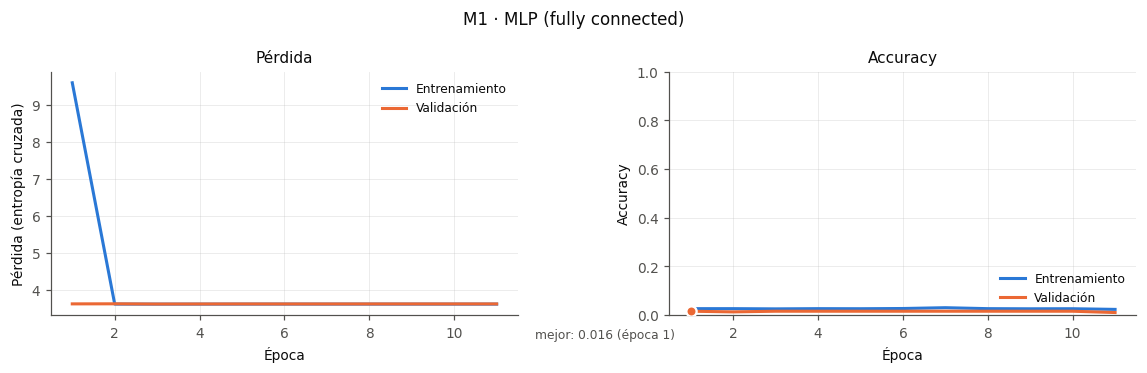

Diagnosticando si el modelo sufre overfitting o underfitting 🩺
Mejor época            : 1 de 11
Accuracy entrenamiento : 2.69 %
Accuracy validación    : 1.63 %
Brecha (ent - val)     : +1.06 puntos
=> UNDERFITTING: el modelo no logra ajustar ni siquiera los datos de entrenamiento.

Evaluando el modelo sobre el conjunto de validación 🧪
  validación: pérdida 3.6137 | accuracy 3.12 % | top-3 8.83 %
Registrando las métricas del modelo para la comparativa final 🗂
Contando los parámetros totales y entrenables del modelo 🧮
Parámetros: 39,462,949 totales | 39,462,949 entrenables


In [ ]:
metricas_m1, diagnostico_m1 = evaluar_y_registrar(
    clave="m1",
    nombre_legible="M1 · MLP (fully connected)",
    descripcion="Imágenes aplanadas, 2 capas densas + dropout. Referencia sin convoluciones.",
    modelo=modelo_m1,
    registro=registro_m1,
    val_ds=val_ds,
)

### 8. Modelo CNN básica

Este modelo introduce **una única familia de cambios** respecto al Modelo 1: sustituye las capas densas
iniciales por bloques convolucionales. Todo lo demás (optimizador, tasa de aprendizaje, protocolo de
entrenamiento, normalización) se mantiene, de modo que **cualquier diferencia de rendimiento es atribuible a
la convolución**.

La arquitectura sigue el patrón clásico tipo VGG: tres bloques `Conv2D → MaxPooling2D` con el número de
filtros duplicándose en cada bloque (32 → 64 → 128), seguidos de un clasificador denso.

**El porqué de duplicar los filtros al reducir la resolución.** Cada `MaxPooling2D(2,2)` divide entre cuatro
el número de posiciones espaciales. Duplicar los filtros compensa parcialmente esa pérdida de capacidad y
refleja un hecho de la jerarquía visual: hay pocos tipos de borde elemental, pero muchísimas combinaciones
posibles de partes de objeto, de modo que las capas profundas necesitan más canales.

Deliberadamente **no** incorpora *batch normalization*, ni *dropout* convolucional, ni *data augmentation*,
ni GAP: mantiene `Flatten`. El objetivo es doble: medir el salto que aporta la convolución por sí sola y
**exhibir el sobreajuste** que motiva el Modelo 3.

#### 8.1 Arquitectura

In [ ]:
# =====================================================================
# 9. Modelo 2: CNN propia básica (patrón VGG reducido, sin regularización)
# =====================================================================

HP_M2 = {
    "arquitectura": "3 x [Conv3x3 -> MaxPool] (32/64/128) -> Flatten -> Dense(128) -> Softmax",
    "filtros": [32, 64, 128],
    "kernel": 3,
    "clasificador": "Flatten + Dense(128)",
    "optimizador": "adam",
    "tasa_aprendizaje": 1e-3,
    "regularizacion": "ninguna",
    "data_augmentation": False,
}


def bloque_convolucional_simple(x, filtros, indice):
    """Bloque Conv2D + MaxPooling2D usado por el Modelo 2."""
    print(f"Añadiendo el bloque {indice}: Conv2D de {filtros} filtros 3x3 + MaxPooling 2x2 🧩")
    x = keras.layers.Conv2D(filtros, 3, padding="same", activation="relu",
                            name=f"conv_{indice}")(x)
    x = keras.layers.MaxPooling2D(2, name=f"pool_{indice}")(x)
    return x


def construir_cnn_basica(filtros=(32, 64, 128), unidades_densa=128, tasa_aprendizaje=1e-3):
    """Modelo 2: CNN convencional sin técnicas de regularización."""
    print("Construyendo el Modelo 2: CNN propia básica, sin regularización 🧠")
    entradas = keras.Input(shape=FORMA_ENTRADA, name="entrada")
    x = keras.layers.Rescaling(1.0 / 255, name="normalizacion")(entradas)
    for indice, n_filtros in enumerate(filtros, start=1):
        x = bloque_convolucional_simple(x, n_filtros, indice)
    x = keras.layers.Flatten(name="aplanado")(x)
    x = keras.layers.Dense(unidades_densa, activation="relu", name="densa")(x)
    salidas = keras.layers.Dense(NUM_CLASES, activation="softmax", name="salida")(x)

    modelo = keras.Model(entradas, salidas, name="m2_cnn_basica")
    return compilar_modelo(modelo, tasa_aprendizaje, HP_M2["optimizador"])


construir_cnn_basica().summary()

Construyendo el Modelo 2: CNN propia básica, sin regularización 🧠
Añadiendo el bloque 1: Conv2D de 32 filtros 3x3 + MaxPooling 2x2 🧩
Añadiendo el bloque 2: Conv2D de 64 filtros 3x3 + MaxPooling 2x2 🧩
Añadiendo el bloque 3: Conv2D de 128 filtros 3x3 + MaxPooling 2x2 🧩
Compilando el modelo con su optimizador adam, su función de pérdida y sus métricas ⚙


Model: "m2_cnn_basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion (Rescaling)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aplanado (Flatten)              │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,651,749 (25.37 MB)

 Trainable params: 6,651,749 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

#### 8.2 Entrenamiento y resultados

In [ ]:
modelo_m2, registro_m2 = entrenar_o_cargar(
    nombre="m2_cnn_basica",
    funcion_constructora=construir_cnn_basica,
    train_ds=train_ds,
    val_ds=val_ds,
    epocas=EPOCAS["m2_cnn_basica"],
    paciencia_parada=10,
    paciencia_lr=4,
    hiperparametros=HP_M2,
)

Entrenando el modelo 'm2_cnn_basica', o recuperándolo del disco si ya fue entrenado 🚀
[m2_cnn_basica] modelo recuperado de disco (14 épocas, 1.2 min de entrenamiento original). Usar forzar_reentrenamiento=True para reentrenar.


Ejecutando el bloque de análisis del modelo: curvas, diagnóstico, evaluación y registro 🧾
Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉


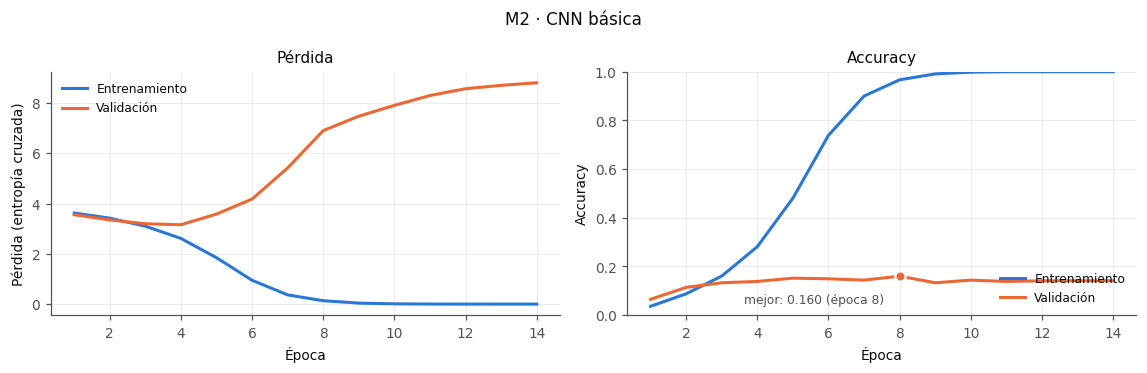

Diagnosticando si el modelo sufre overfitting o underfitting 🩺
Mejor época            : 8 de 14
Accuracy entrenamiento : 96.68 %
Accuracy validación    : 16.03 %
Brecha (ent - val)     : +80.65 puntos
Aviso: la pérdida de validación final supera en >15 % a su mínimo (síntoma de sobreajuste en las últimas épocas; el checkpoint guardado es anterior).
=> OVERFITTING: brecha de 80.6 puntos entre entrenamiento y validación (umbral 10).

Evaluando el modelo sobre el conjunto de validación 🧪
  validación: pérdida 3.4841 | accuracy 57.07 % | top-3 66.85 %
Registrando las métricas del modelo para la comparativa final 🗂
Contando los parámetros totales y entrenables del modelo 🧮
Parámetros: 6,651,749 totales | 6,651,749 entrenables


In [ ]:
metricas_m2, diagnostico_m2 = evaluar_y_registrar(
    clave="m2",
    nombre_legible="M2 · CNN básica",
    descripcion="3 bloques Conv+Pool sin regularización ni aumento de datos.",
    modelo=modelo_m2,
    registro=registro_m2,
    val_ds=val_ds,
)

#### 8.3 Conclusión

La CNN básica **multiplica varias veces la *accuracy* del MLP usando muchos menos parámetros**, lo que
constituye la primera evidencia experimental clara del trabajo: el sesgo inductivo importa más que la
capacidad bruta del modelo. Conectividad local, pesos compartidos e invarianza a la traslación son
exactamente las propiedades que este dominio requiere.

Sin embargo, el diagnóstico revela un **sobreajuste severo**: la *accuracy* de entrenamiento sigue subiendo
mientras la de validación se estanca, y la pérdida de validación llega a repuntar. Las causas son
identificables y todas se abordan en el Modelo 3:

1. **`Flatten` tras el último bloque** concentra la inmensa mayoría de los parámetros en una sola capa densa.
2. **Ausencia de regularización**: sin *dropout* ni penalización L2, nada limita la memorización.
3. **Sin *data augmentation***, la red ve exactamente las mismas ~3 300 imágenes en cada época.
4. **Sin *batch normalization***, la optimización es más inestable y no se beneficia de su efecto
   regularizador.

### CNN propia profunda con regularización y data augmentation

Es la **arquitectura propia** del trabajo. Corrige de forma sistemática cada una de las cuatro debilidades
detectadas en el Modelo 2, aplicando el conjunto completo de técnicas descritas en las secciones 6.5 y 6.6:

| Debilidad del M2 | Solución en el M3 | Fundamento (sección) |
|---|---|---|
| `Flatten` con millones de parámetros | `GlobalAveragePooling2D` | 6.3 |
| Sin regularización | *Dropout* creciente (0,15 → 0,45) + L2 ($10^{-4}$) | 6.6 |
| Sin *data augmentation* | 5 transformaciones aleatorias integradas en el modelo | 5.2 |
| Optimización inestable | `BatchNormalization` tras cada convolución | 6.5 |
| Campo receptivo limitado | 4 bloques con **doble** convolución 3×3 cada uno | 6.2 |

**Decisiones de diseño destacadas:**

* **Doble convolución 3×3 por bloque.** Dos convoluciones 3×3 consecutivas equivalen a un campo receptivo de
  5×5 con menos parámetros y una no linealidad adicional (sección 6.2).
* **Orden Conv → BN → ReLU.** Es el orden propuesto en el artículo original: la normalización actúa sobre los
  *logits* de la convolución, antes de la no linealidad. Por eso las capas `Conv2D` se declaran con
  `activation=None` y la ReLU se añade como capa independiente. Además, al normalizar se elimina la necesidad
  del término de sesgo (`use_bias=False`), pues $\beta$ cumple esa función.
* ***Dropout* creciente con la profundidad.** Las primeras capas extraen características genéricas de bajo
  nivel que conviene preservar; las profundas son las que memorizan detalles específicos, y son las que más
  regularización necesitan.
* **Cuatro bloques.** Con entrada de 160 px, cuatro reducciones sucesivas llevan la resolución a
  $160 \to 80 \to 40 \to 20 \to 10$, un tamaño adecuado para el GAP final.

#### 9.1 Arquitectura

In [ ]:
# =====================================================================
# 10. Modelo 3: CNN profunda propia (BN + Dropout + L2 + augmentation)
# =====================================================================

HP_M3 = {
    "arquitectura": "4 x [2 x (Conv3x3+BN+ReLU) -> MaxPool -> Dropout] -> GAP -> Dense(256) -> Softmax",
    "filtros": [32, 64, 128, 256],
    "dropout_bloques": [0.15, 0.20, 0.25, 0.30],
    "dropout_clasificador": 0.45,
    "l2": 1e-4,
    "optimizador": "adam",
    "tasa_aprendizaje": 1e-3,
    "data_augmentation": True,
    "clasificador": "GlobalAveragePooling2D + Dense(256)",
}


def bloque_convolucional_doble(x, filtros, tasa_dropout, indice, l2):
    """Bloque: 2 x (Conv3x3 -> BatchNorm -> ReLU) -> MaxPool -> Dropout."""
    print(f"Añadiendo el bloque {indice}: 2x(Conv {filtros} filtros + BN + ReLU) "
          f"+ MaxPool + Dropout({tasa_dropout}) 🧩")
    for sub in (1, 2):
        x = keras.layers.Conv2D(
            filtros, 3, padding="same", use_bias=False,
            kernel_regularizer=keras.regularizers.l2(l2),
            name=f"conv_{indice}_{sub}",
        )(x)
        x = keras.layers.BatchNormalization(name=f"bn_{indice}_{sub}")(x)
        x = keras.layers.Activation("relu", name=f"relu_{indice}_{sub}")(x)
    x = keras.layers.MaxPooling2D(2, name=f"pool_{indice}")(x)
    x = keras.layers.Dropout(tasa_dropout, name=f"dropout_{indice}")(x)
    return x


def construir_cnn_profunda(filtros=(32, 64, 128, 256),
                           dropout_bloques=(0.15, 0.20, 0.25, 0.30),
                           dropout_clasificador=0.45, l2=1e-4,
                           unidades_densa=256, tasa_aprendizaje=1e-3,
                           usar_aumentacion=True):
    """Modelo 3: arquitectura convolucional propia, profunda y regularizada."""
    print("Construyendo el Modelo 3: CNN propia profunda con regularización y data augmentation 🏗")
    entradas = keras.Input(shape=FORMA_ENTRADA, name="entrada")

    # El aumento de datos forma parte del modelo: Keras lo aplica solo en
    # entrenamiento y lo desactiva en evaluate() / predict().
    x = crear_aumentador()(entradas) if usar_aumentacion else entradas
    x = keras.layers.Rescaling(1.0 / 255, name="normalizacion")(x)

    for indice, (n_filtros, p) in enumerate(zip(filtros, dropout_bloques), start=1):
        x = bloque_convolucional_doble(x, n_filtros, p, indice, l2)

    x = keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = keras.layers.Dense(unidades_densa, use_bias=False,
                           kernel_regularizer=keras.regularizers.l2(l2), name="densa")(x)
    x = keras.layers.BatchNormalization(name="bn_densa")(x)
    x = keras.layers.Activation("relu", name="relu_densa")(x)
    x = keras.layers.Dropout(dropout_clasificador, name="dropout_clasificador")(x)
    salidas = keras.layers.Dense(NUM_CLASES, activation="softmax", name="salida")(x)

    modelo = keras.Model(entradas, salidas, name="m3_cnn_profunda")
    return compilar_modelo(modelo, tasa_aprendizaje, HP_M3["optimizador"])


construir_cnn_profunda().summary()

Construyendo el Modelo 3: CNN propia profunda con regularización y data augmentation 🏗
Creando el bloque de data augmentation: volteo, rotación, zoom, traslación y contraste 🔄
Añadiendo el bloque 1: 2x(Conv 32 filtros + BN + ReLU) + MaxPool + Dropout(0.15) 🧩
Añadiendo el bloque 2: 2x(Conv 64 filtros + BN + ReLU) + MaxPool + Dropout(0.2) 🧩
Añadiendo el bloque 3: 2x(Conv 128 filtros + BN + ReLU) + MaxPool + Dropout(0.25) 🧩
Añadiendo el bloque 4: 2x(Conv 256 filtros + BN + ReLU) + MaxPool + Dropout(0.3) 🧩
Compilando el modelo con su optimizador adam, su función de pérdida y sus métricas ⚙


Model: "m3_cnn_profunda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumentacion (Sequential)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion (Rescaling)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_1 (Conv2D)               │ (None, 160, 160, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_1 (BatchNormalization)     │ (None, 160, 160, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1_1 (Activation)           │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_2 (Conv2D)               │ (None, 160, 160, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1_2 (BatchNormalization)     │ (None, 160, 160, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1_2 (Activation)           │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_1 (BatchNormalization)     │ (None, 80, 80, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2_1 (Activation)           │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_2 (Conv2D)               │ (None, 80, 80, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2_2 (BatchNormalization)     │ (None, 80, 80, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2_2 (Activation)           │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_1 (Conv2D)               │ (None, 40, 40, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3_1 (BatchNormalization)     │ (None, 40, 40, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3_1 (Activation)           │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_2 (Conv2D)               │ (None, 40, 40, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3_2 (BatchNormalization)     │ (None, 40, 40, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3_2 (Activation)           │ (None, 40, 40, 128)    │             

 Total params: 1,251,205 (4.77 MB)

 Trainable params: 1,248,773 (4.76 MB)

 Non-trainable params: 2,432 (9.50 KB)

#### 9.2 Entrenamiento y resultados

Al incorporar *data augmentation* el modelo ve datos distintos en cada época, por lo que necesita
**más épocas** para converger (de ahí el límite de 80) y se le concede una paciencia mayor en la parada
temprana.

In [ ]:
modelo_m3, registro_m3 = entrenar_o_cargar(
    nombre="m3_cnn_profunda",
    funcion_constructora=construir_cnn_profunda,
    train_ds=train_ds,
    val_ds=val_ds,
    epocas=EPOCAS["m3_cnn_profunda"],
    paciencia_parada=15,
    paciencia_lr=6,
    hiperparametros=HP_M3,
)

Entrenando el modelo 'm3_cnn_profunda', o recuperándolo del disco si ya fue entrenado 🚀
[m3_cnn_profunda] modelo recuperado de disco (60 épocas, 17.7 min de entrenamiento original). Usar forzar_reentrenamiento=True para reentrenar.


Ejecutando el bloque de análisis del modelo: curvas, diagnóstico, evaluación y registro 🧾
Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉


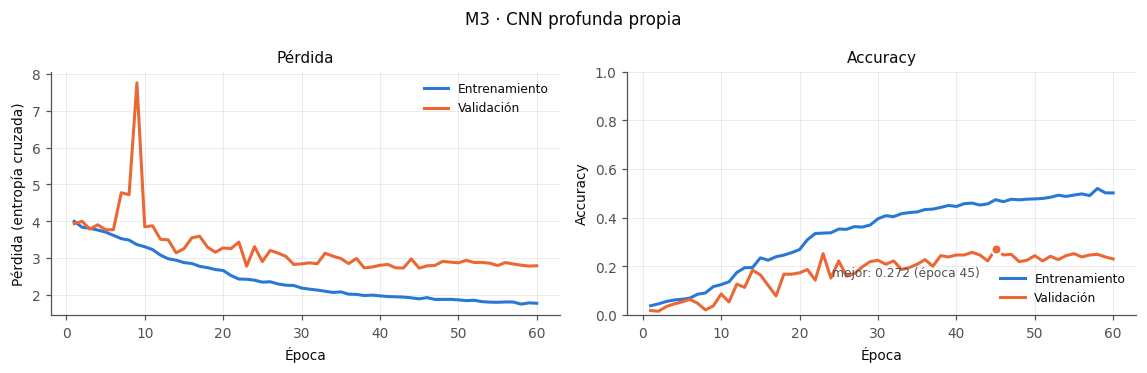

Diagnosticando si el modelo sufre overfitting o underfitting 🩺
Mejor época            : 45 de 60
Accuracy entrenamiento : 47.43 %
Accuracy validación    : 27.17 %
Brecha (ent - val)     : +20.26 puntos
=> OVERFITTING: brecha de 20.3 puntos entre entrenamiento y validación (umbral 10).

Evaluando el modelo sobre el conjunto de validación 🧪
  validación: pérdida 2.5962 | accuracy 28.94 % | top-3 58.15 %
Registrando las métricas del modelo para la comparativa final 🗂
Contando los parámetros totales y entrenables del modelo 🧮
Parámetros: 1,251,205 totales | 1,248,773 entrenables


In [ ]:
metricas_m3, diagnostico_m3 = evaluar_y_registrar(
    clave="m3",
    nombre_legible="M3 · CNN profunda propia",
    descripcion="4 bloques dobles Conv+BN, dropout creciente, L2, GAP y data augmentation.",
    modelo=modelo_m3,
    registro=registro_m3,
    val_ds=val_ds,
)

#### 9.3 Conclusiones

El efecto de la regularización es inequívoco en las curvas: **las curvas de entrenamiento y validación
avanzan juntas** durante la mayor parte del entrenamiento, en lugar de divergir como en el Modelo 2. La
brecha se reduce drásticamente y, de hecho, en las primeras épocas la *accuracy* de validación suele ser
**superior** a la de entrenamiento —un fenómeno esperado y a menudo malinterpretado: las métricas de
entrenamiento se calculan sobre imágenes **aumentadas** (más difíciles) y con *dropout* activo, mientras que
las de validación se calculan sobre imágenes limpias y con la red completa.

El modelo mejora al M2 tanto en *accuracy* como en estabilidad, y usa **menos parámetros** gracias al GAP.
Sin embargo, sigue lejos del objetivo del 85 %, y la causa **no es la arquitectura sino los datos**: ~90
imágenes por clase son sencillamente insuficientes para que una red aprenda desde cero las características
de grano fino que distinguen un *American Bulldog* de un *American Pit Bull Terrier*. Este es el límite
práctico del entrenamiento desde cero en este problema y el argumento que motiva los modelos 4 y 5.

### 10. Transfer Learning con MobileNetv2 (Extracción de características)

Los tres modelos anteriores comparten una limitación insalvable: deben aprender **desde cero**, con ~$3,312$
imágenes, todo lo que hay que saber sobre bordes, texturas, formas y partes de animal. MobileNetV2
preentrenada en ImageNet ya lo sabe: ha visto 1,28 millones de imágenes, entre ellas ~120 razas de perro.

En esta primera estrategia el modelo base se usa como **extractor de características
congelado**:

```
entrada 160×160×3
   └─ data augmentation                (solo en entrenamiento)
   └─ Rescaling(1/127.5, offset=-1)    → rango [-1, 1], el de MobileNetV2
   └─ MobileNetV2 (congelada)          → mapa de 5×5×1280
   └─ GlobalAveragePooling2D           → vector de 1280 características
   └─ Dropout(0.3)
   └─ Dense(37, softmax)               → única parte entrenable
```

**Tres detalles de implementación decisivos:**

1. **La normalización debe ser la original de MobileNetV2** ($[-1,1]$). Se implementa con
   `Rescaling(1/127.5, offset=-1)`, que es exactamente lo que hace `mobilenet_v2.preprocess_input`, pero como
   capa serializable dentro del modelo.
2. **El modelo base se invoca con `training=False`** en el grafo funcional. Esto fuerza a sus capas de
   *batch normalization* a usar siempre las estadísticas de ImageNet, tanto ahora como durante el
   *fine-tuning* posterior.
3. **Se mantiene el *data augmentation***: aunque solo se entrenen ~47 K parámetros, la cabeza también puede
   sobreajustar, y el aumento apenas encarece el entrenamiento.

Solo se entrenan $1280 \times 37 + 37 = 47\,397$ parámetros, frente a los ~2,3 M congelados del modelo base.

#### 10.1 Arquitectura

In [ ]:
# =====================================================================
# 11. Modelo 4: MobileNetV2 congelada + cabeza de clasificación
# =====================================================================

HP_M4 = {
    "modelo_base": "MobileNetV2 (ImageNet, include_top=False, alpha=1.0)",
    "estrategia": "extracción de características (base congelada)",
    "cabeza": "GAP -> Dropout(0.3) -> Dense(37, softmax)",
    "preproceso": "[-1, 1] (Rescaling 1/127.5, offset=-1)",
    "optimizador": "adam",
    "tasa_aprendizaje": 1e-3,
    "data_augmentation": True,
}


def crear_base_mobilenet(entrenable=False):
    """Carga MobileNetV2 preentrenada en ImageNet, sin su clasificador."""
    print("Cargando MobileNetV2 preentrenada en ImageNet, sin su clasificador 📦")
    base = keras.applications.MobileNetV2(
        input_shape=FORMA_ENTRADA,
        include_top=False,
        weights="imagenet",
    )
    base.trainable = entrenable
    return base


def obtener_submodelo_base(modelo):
    """Localiza el modelo preentrenado anidado dentro de un modelo compuesto."""
    print("Localizando el modelo preentrenado anidado dentro del modelo compuesto 🔎")
    for capa in modelo.layers:
        if isinstance(capa, keras.Model) and len(capa.layers) > 20:
            return capa
    raise ValueError("No se encontró el modelo base preentrenado.")


def construir_transfer(tasa_dropout=0.3, tasa_aprendizaje=1e-3, usar_aumentacion=True):
    """Modelo 4: extracción de características con MobileNetV2 congelada."""
    print("Construyendo el Modelo 4: transfer learning con la base congelada ♻")
    base = crear_base_mobilenet(entrenable=False)

    entradas = keras.Input(shape=FORMA_ENTRADA, name="entrada")
    x = crear_aumentador()(entradas) if usar_aumentacion else entradas
    # Preprocesado propio de MobileNetV2: [0,255] -> [-1,1]
    x = keras.layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preproceso_mobilenet")(x)
    # training=False fija las capas BatchNormalization en modo inferencia.
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = keras.layers.Dropout(tasa_dropout, name="dropout_clasificador")(x)
    salidas = keras.layers.Dense(NUM_CLASES, activation="softmax", name="salida")(x)

    modelo = keras.Model(entradas, salidas, name="m4_transfer")
    return compilar_modelo(modelo, tasa_aprendizaje, HP_M4["optimizador"])


_m4_demo = construir_transfer()
_tot, _ent = contar_parametros(_m4_demo)
_m4_demo.summary()
print(f"\nParámetros congelados: {_tot - _ent:,} | entrenables: {_ent:,} "
      f"({100 * _ent / _tot:.1f} % del total)")

Construyendo el Modelo 4: transfer learning con la base congelada ♻
Cargando MobileNetV2 preentrenada en ImageNet, sin su clasificador 📦
Creando el bloque de data augmentation: volteo, rotación, zoom, traslación y contraste 🔄
Compilando el modelo con su optimizador adam, su función de pérdida y sus métricas ⚙
Contando los parámetros totales y entrenables del modelo 🧮


Model: "m4_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumentacion (Sequential)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preproceso_mobilenet            │ (None, 160, 160, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_clasificador (Dropout)  │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parámetros congelados: 2,257,984 | entrenables: 47,397 (2.1 % del total)


#### 10.2 Entrenamiento y resultados

In [ ]:
modelo_m4, registro_m4 = entrenar_o_cargar(
    nombre="m4_transfer",
    funcion_constructora=construir_transfer,
    train_ds=train_ds,
    val_ds=val_ds,
    epocas=EPOCAS["m4_transfer"],
    paciencia_parada=8,
    paciencia_lr=3,
    hiperparametros=HP_M4,
)

Entrenando el modelo 'm4_transfer', o recuperándolo del disco si ya fue entrenado 🚀
[m4_transfer] modelo recuperado de disco (30 épocas, 2.5 min de entrenamiento original). Usar forzar_reentrenamiento=True para reentrenar.


Ejecutando el bloque de análisis del modelo: curvas, diagnóstico, evaluación y registro 🧾
Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉


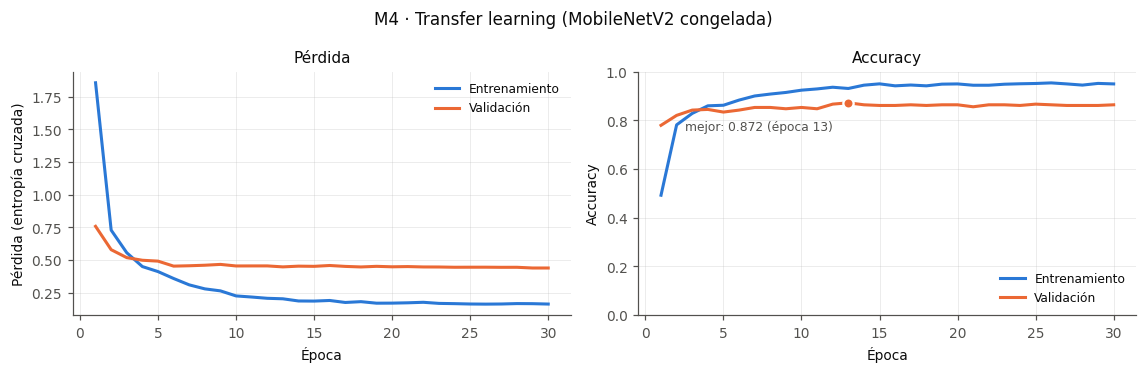

Diagnosticando si el modelo sufre overfitting o underfitting 🩺
Mejor época            : 13 de 30
Accuracy entrenamiento : 93.12 %
Accuracy validación    : 87.23 %
Brecha (ent - val)     : +5.89 puntos
=> AJUSTE CORRECTO: brecha de 5.9 puntos, dentro del margen aceptable.

Evaluando el modelo sobre el conjunto de validación 🧪
  validación: pérdida 0.3106 | accuracy 91.17 % | top-3 98.37 %
Registrando las métricas del modelo para la comparativa final 🗂
Contando los parámetros totales y entrenables del modelo 🧮
Parámetros: 2,305,381 totales | 47,397 entrenables


In [ ]:
metricas_m4, diagnostico_m4 = evaluar_y_registrar(
    clave="m4",
    nombre_legible="M4 · Transfer learning (MobileNetV2 congelada)",
    descripcion="Extractor de características ImageNet congelado + cabeza densa entrenada.",
    modelo=modelo_m4,
    registro=registro_m4,
    val_ds=val_ds,
)

#### 10.3 Conclusiones

El salto respecto a la mejor arquitectura propia es **de decenas de puntos**, y se produce entrenando
únicamente ~47 K parámetros durante muy pocas épocas. Esto confirma la hipótesis planteada en la sección 1.1:
en un régimen de datos escasos, **la calidad de las representaciones preentrenadas pesa mucho más que el
diseño de la arquitectura**.

Observaciones sobre las curvas:

* La convergencia es **muy rápida**: en las primeras épocas ya se supera el resultado final de cualquier
  modelo entrenado desde cero. Se está resolviendo un problema de regresión logística multinomial sobre
  características de altísima calidad, que es un problema convexo y bien condicionado.
* La brecha entrenamiento-validación es **pequeña**: con solo la cabeza entrenable la capacidad de memorizar
  es limitada.
* La curva de validación se **aplana** pronto. Ese estancamiento es informativo: las características de
  ImageNet son genéricas y ya no pueden mejorar más sin **especializarse** en las razas concretas del
  problema. Justamente eso es lo que hace el Modelo 5.

### 11. Fine- Tuning de MobileNetv2

El *fine-tuning* parte del Modelo 4 **ya entrenado** y descongela las **últimas 40 capas** del modelo base
para reentrenarlas junto con la cabeza, empleando una tasa de aprendizaje muy pequeña ($10^{-5}$, cien veces
menor que la del Modelo 4).

**Por qué solo las últimas capas.** En una CNN profunda existe un gradiente de especificidad: las primeras
capas detectan bordes y colores —útiles para cualquier imagen natural, no hay nada que mejorar en ellas— y
las últimas codifican conceptos específicos del dominio de origen. Son estas últimas las que deben
reorientarse hacia las 37 razas del problema. Descongelar la red entera con tan pocos datos provocaría
sobreajuste y destruiría representaciones valiosas.

**Por qué una tasa de aprendizaje tan baja.** Los pesos preentrenados están cerca de un buen mínimo. Con
$\eta = 10^{-3}$, las primeras actualizaciones los desplazarían tanto que se perdería el conocimiento
adquirido en ImageNet (*catastrophic forgetting*). Con $\eta = 10^{-5}$ se hace un ajuste fino.

**Por qué la cabeza debía entrenarse primero.** Si se descongelara la base con una cabeza inicializada al
azar, los gradientes iniciales —enormes, procedentes de una salida esencialmente aleatoria— se
retropropagarían a la base y arruinarían sus pesos. Este es el motivo por el que el Modelo 5 se construye
**cargando el punto de control del Modelo 4** en lugar de construirse de cero.

**Por qué la *batch normalization* permanece congelada.** Tal como se explicó en la sección 6.5, el modelo
base se invoca con `training=False` (sus estadísticas móviles nunca se actualizan) y además se marcan sus
capas `BatchNormalization` como no entrenables, de modo que tampoco se actualicen $\gamma$ y $\beta$. Es el
error más habitual —y más difícil de diagnosticar— del *fine-tuning*.

#### 11.1 Construcción a partir del modelo 4

In [ ]:
# =====================================================================
# 12. Modelo 5: fine-tuning de las últimas capas de MobileNetV2
# =====================================================================

HP_M5 = {
    "modelo_base": "MobileNetV2 preentrenada + cabeza del M4 ya entrenada",
    "estrategia": "fine-tuning de las últimas 40 capas (BatchNorm congelada)",
    "capas_descongeladas": 40,
    "optimizador": "adam",
    "tasa_aprendizaje": 1e-5,
    "data_augmentation": True,
}


def descongelar_ultimas_capas(base, n_capas=40):
    """Hace entrenables las n últimas capas del modelo base, salvo las de BatchNorm.

    Las capas de normalización por lotes se mantienen congeladas para preservar las
    estadísticas aprendidas sobre ImageNet (sección 6.5).
    """
    print("Descongelando las últimas capas del modelo base, manteniendo congelada la BatchNorm 🔓")
    base.trainable = True
    for capa in base.layers[:-n_capas]:
        capa.trainable = False
    for capa in base.layers[-n_capas:]:
        capa.trainable = not isinstance(capa, keras.layers.BatchNormalization)
    return base


def construir_fine_tuning(nombre_modelo_previo="m4_transfer", n_capas=40, tasa_aprendizaje=1e-5):
    """Modelo 5: parte del mejor punto de control del Modelo 4 y descongela la base."""
    print("Construyendo el Modelo 5: fine-tuning a partir del mejor punto de control del Modelo 4 🔥")
    modelo = keras.models.load_model(_ruta_modelo(nombre_modelo_previo))
    base = obtener_submodelo_base(modelo)
    descongelar_ultimas_capas(base, n_capas)
    modelo._name = "m5_finetuning"
    return compilar_modelo(modelo, tasa_aprendizaje, HP_M5["optimizador"])


_m5_demo = construir_fine_tuning()
_tot5, _ent5 = contar_parametros(_m5_demo)
_base_demo = obtener_submodelo_base(_m5_demo)
print(f"Capas del modelo base            : {len(_base_demo.layers)}")
print(f"Capas base entrenables           : {sum(c.trainable for c in _base_demo.layers)}")
print(f"Parámetros totales               : {_tot5:,}")
print(f"Parámetros entrenables           : {_ent5:,} ({100 * _ent5 / _tot5:.1f} %)")
del _m5_demo, _base_demo

Construyendo el Modelo 5: fine-tuning a partir del mejor punto de control del Modelo 4 🔥
Localizando el modelo preentrenado anidado dentro del modelo compuesto 🔎
Descongelando las últimas capas del modelo base, manteniendo congelada la BatchNorm 🔓
Compilando el modelo con su optimizador adam, su función de pérdida y sus métricas ⚙
Contando los parámetros totales y entrenables del modelo 🧮
Localizando el modelo preentrenado anidado dentro del modelo compuesto 🔎
Capas del modelo base            : 154
Capas base entrenables           : 26
Parámetros totales               : 2,305,381
Parámetros entrenables           : 1,710,757 (74.2 %)


#### 11.2 Entrenamiento y resultados

In [ ]:
modelo_m5, registro_m5 = entrenar_o_cargar(
    nombre="m5_finetuning",
    funcion_constructora=construir_fine_tuning,
    train_ds=train_ds,
    val_ds=val_ds,
    epocas=EPOCAS["m5_finetuning"],
    paciencia_parada=6,
    paciencia_lr=3,
    hiperparametros=HP_M5,
)

Entrenando el modelo 'm5_finetuning', o recuperándolo del disco si ya fue entrenado 🚀
[m5_finetuning] modelo recuperado de disco (14 épocas, 1.5 min de entrenamiento original). Usar forzar_reentrenamiento=True para reentrenar.


Ejecutando el bloque de análisis del modelo: curvas, diagnóstico, evaluación y registro 🧾
Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉


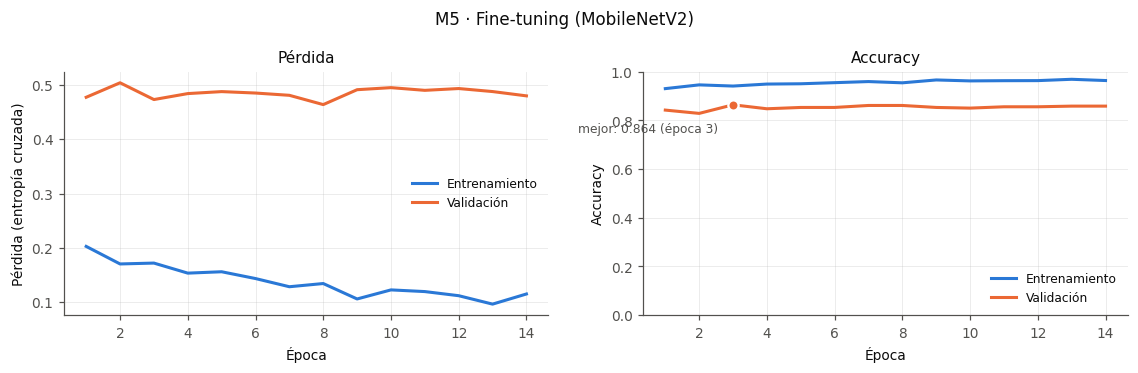

Diagnosticando si el modelo sufre overfitting o underfitting 🩺
Mejor época            : 3 de 14
Accuracy entrenamiento : 94.11 %
Accuracy validación    : 86.41 %
Brecha (ent - val)     : +7.70 puntos
=> AJUSTE CORRECTO: brecha de 7.7 puntos, dentro del margen aceptable.

Evaluando el modelo sobre el conjunto de validación 🧪
  validación: pérdida 0.3074 | accuracy 90.90 % | top-3 98.23 %
Registrando las métricas del modelo para la comparativa final 🗂
Contando los parámetros totales y entrenables del modelo 🧮
Parámetros: 2,305,381 totales | 1,710,757 entrenables


In [ ]:
metricas_m5, diagnostico_m5 = evaluar_y_registrar(
    clave="m5",
    nombre_legible="M5 · Fine-tuning (MobileNetV2)",
    descripcion="Últimas 40 capas de MobileNetV2 reentrenadas con lr=1e-5 sobre la cabeza del M4.",
    modelo=modelo_m5,
    registro=registro_m5,
    val_ds=val_ds,
)

#### 11.3 Conclusiones

El *fine-tuning* aporta una mejora adicional sobre el Modelo 4 **desde la primera época**, lo que confirma
que el modelo partía de un punto ya bueno y que el ajuste está siendo fino, no destructivo. La especialización
de las últimas capas convolucionales permite capturar precisamente los detalles de grano fino —textura del
pelaje, forma del hocico, proporción de las orejas— que distinguen razas emparentadas y que las
características genéricas de ImageNet no separaban.

Puntos que conviene destacar:

* El entrenamiento es **corto y controlado**: con $\eta = 10^{-5}$ y pocas épocas, la parada temprana actúa
  pronto. El riesgo de sobreajuste es real, porque ahora hay más de un millón de parámetros entrenables, y por
  eso la paciencia se reduce a 6 épocas.
* La **top-3 accuracy** es sensiblemente superior a la *accuracy*, lo que indica que en la mayoría de los
  errores la clase correcta sigue estando entre las candidatas más probables: son confusiones entre razas
  similares, no fallos categóricos.
* Es el modelo con mejor *accuracy* de validación y, salvo sorpresa, el que se llevará a la evaluación final
  sobre test.

### 12. Comparativa experimenta de los cinco modelos

Se reúnen ahora, sobre el **conjunto de validación** (el conjunto de test sigue sin utilizarse), todas las
cifras registradas por `registrar_resultado()`: *accuracy*, top-3, pérdida, número de parámetros, épocas
ejecutadas, tiempo de entrenamiento y brecha entrenamiento-validación.

In [ ]:
# =====================================================================
# 13. Funciones de comparación
# =====================================================================

# Paleta categórica: un color por modelo, asignado por identidad (no por rango)
# y siempre en el mismo orden.
PALETA_MODELOS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]


def tabla_comparativa(resultados):
    """Imprime la tabla resumen de todos los modelos entrenados."""
    print("Comparando en una tabla los cinco modelos entrenados 🏆")
    encabezado = (f"{'Modelo':<48}{'Params':>12}{'Entren.':>12}{'Épocas':>8}"
                  f"{'Acc val':>10}{'Top-3':>9}{'Brecha':>9}{'Min':>7}")
    print(encabezado)
    print("-" * len(encabezado))
    for clave, r in resultados.items():
        print(f"{r['nombre']:<48}{r['parametros']:>12,}{r['parametros_entrenables']:>12,}"
              f"{r['epocas']:>8}{r['acc_validacion'] * 100:>9.2f}%{r['top3_validacion'] * 100:>8.2f}%"
              f"{r['brecha'] * 100:>+8.1f}p{r['minutos']:>7.1f}")
    print("-" * len(encabezado))
    mejor = max(resultados, key=lambda k: resultados[k]["acc_validacion"])
    print(f"Mejor modelo según validación: {resultados[mejor]['nombre']} "
          f"({resultados[mejor]['acc_validacion'] * 100:.2f} %)")
    return mejor


def graficar_comparativa(resultados):
    """Dos vistas complementarias: accuracy final por modelo y curvas de validación."""
    print("Dibujando la comparativa de accuracy de validación entre modelos 📊")
    claves = list(resultados)
    nombres = [resultados[k]["nombre"].split(" · ")[0] for k in claves]
    accs = [resultados[k]["acc_validacion"] * 100 for k in claves]

    fig, ejes = plt.subplots(1, 2, figsize=(11.5, 3.8))

    # Panel 1: magnitud -> un solo tono; el mejor se señala con texto, no con color.
    barras = ejes[0].bar(nombres, accs, color=C_SERIE_1, width=0.6)
    ejes[0].bar_label(barras, fmt="%.1f", padding=3, fontsize=8.5)
    ejes[0].axhline(85, color=C_ACENTO, linestyle="--", linewidth=1.2)
    ejes[0].text(len(nombres) - 0.4, 86.5, "objetivo 85 %", fontsize=8, color=C_ACENTO, ha="right")
    ejes[0].set_ylabel("Accuracy de validación (%)")
    ejes[0].set_ylim(0, 105)
    ejes[0].set_title("Accuracy de validación por modelo", fontsize=10)
    ejes[0].grid(axis="x", visible=False)

    # Panel 2: identidad -> un color por modelo, siempre el mismo orden, con leyenda.
    for color, clave in zip(PALETA_MODELOS, claves):
        curva = np.array(resultados[clave]["curva_val"]) * 100
        ejes[1].plot(np.arange(1, len(curva) + 1), curva, color=color,
                     marker="o" if len(curva) < 3 else None, markersize=5,
                     label=resultados[clave]["nombre"].split(" · ")[0])
    ejes[1].axhline(85, color=C_ACENTO, linestyle="--", linewidth=1.2)
    ejes[1].set_xlabel("Época")
    ejes[1].set_ylabel("Accuracy de validación (%)")
    ejes[1].set_ylim(0, 100)
    ejes[1].set_title("Evolución de la accuracy de validación", fontsize=10)
    ejes[1].legend(frameon=False, fontsize=8, loc="lower right", ncol=2)

    fig.tight_layout()
    plt.show()


def graficar_eficiencia(resultados):
    """Accuracy frente a parámetros entrenables (escala logarítmica)."""
    print("Dibujando la accuracy frente al número de parámetros entrenables ⚡")
    fig, eje = plt.subplots(figsize=(6.2, 3.6))
    for color, clave in zip(PALETA_MODELOS, resultados):
        r = resultados[clave]
        eje.scatter(r["parametros_entrenables"], r["acc_validacion"] * 100,
                    s=90, color=color, edgecolors="white", linewidths=1.5, zorder=3)
        eje.annotate(r["nombre"].split(" · ")[0],
                     (r["parametros_entrenables"], r["acc_validacion"] * 100),
                     textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
    eje.set_xscale("log")
    eje.set_xlabel("Parámetros entrenables (escala log)")
    eje.set_ylabel("Accuracy de validación (%)")
    eje.set_ylim(0, 105)
    eje.set_title("Rendimiento frente a capacidad entrenable", fontsize=10)
    fig.tight_layout()
    plt.show()

In [ ]:
# --- Ejecución estructurada: comparativa ------------------------------
CLAVE_MEJOR_MODELO = tabla_comparativa(RESULTADOS)

Comparando en una tabla los cinco modelos entrenados 🏆
Modelo                                                Params     Entren.  Épocas   Acc val    Top-3   Brecha    Min
-------------------------------------------------------------------------------------------------------------------
M1 · MLP (fully connected)                        39,462,949  39,462,949      11     3.12%    8.83%    +1.1p    0.7
M2 · CNN básica                                    6,651,749   6,651,749      14    57.07%   66.85%   +80.6p    1.2
M3 · CNN profunda propia                           1,251,205   1,248,773      60    28.94%   58.15%   +20.3p   17.7
M4 · Transfer learning (MobileNetV2 congelada)     2,305,381      47,397      30    91.17%   98.37%    +5.9p    2.5
M5 · Fine-tuning (MobileNetV2)                     2,305,381   1,710,757      14    90.90%   98.23%    +7.7p    1.5
-------------------------------------------------------------------------------------------------------------------
Mejor modelo segú

Dibujando la comparativa de accuracy de validación entre modelos 📊


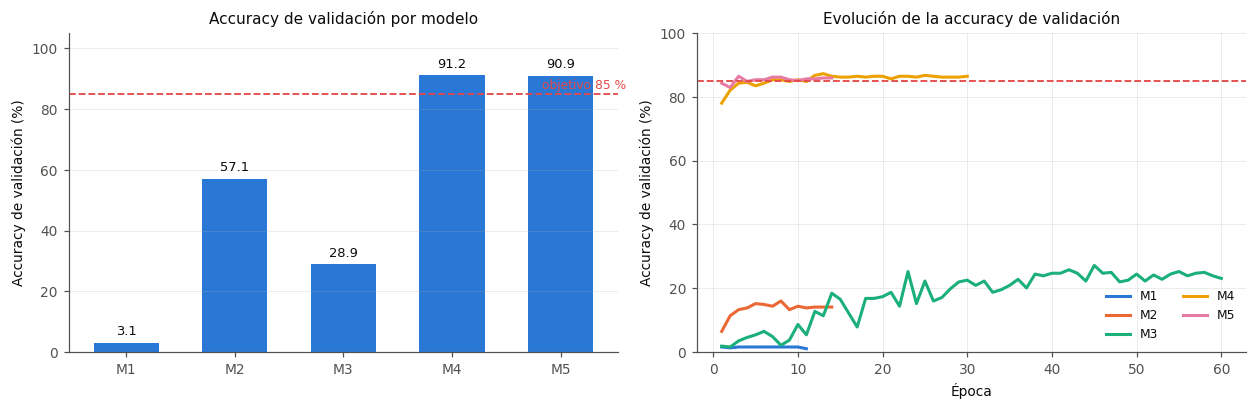

In [ ]:
graficar_comparativa(RESULTADOS)

Dibujando la accuracy frente al número de parámetros entrenables ⚡


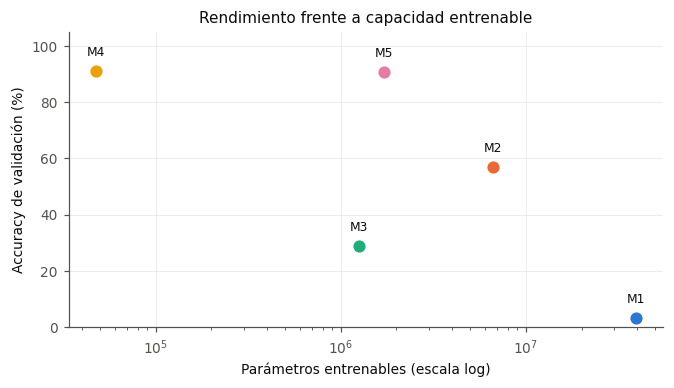

In [ ]:
graficar_eficiencia(RESULTADOS)

#### 12.1 Lectura comparativa

**1. El sesgo inductivo supera a la capacidad.** El MLP (M1) es el modelo con más parámetros de todo el
estudio y el peor de todos. La CNN básica (M2), con una fracción de esos parámetros, lo supera ampliamente.
Aplanar la imagen destruye exactamente la información que hace falta.

**2. La regularización convierte capacidad en generalización.** El M3 tiene menos parámetros que el M2 pero
generaliza mejor, y sobre todo lo hace de forma **estable**: la brecha entrenamiento-validación pasa de ser
severa a ser marginal. *Batch normalization*, *dropout*, L2, GAP y *data augmentation* actúan de forma
complementaria: ninguna de ellas basta por sí sola.

**3. El *transfer learning* cambia el orden de magnitud del problema.** El M4 entrena ~47 K parámetros —tres
órdenes de magnitud menos que el M1— y multiplica su rendimiento. En un régimen de ~90 imágenes por clase,
**los datos que vio el modelo base valen más que cualquier decisión de arquitectura propia**. El gráfico de
eficiencia lo muestra con claridad: los dos modelos de la derecha (más parámetros entrenables) no son los
mejores; los mejores son los que **reutilizan conocimiento**.

**4. El *fine-tuning* aporta la última mejora, y solo funciona en el orden correcto.** Especializar las
últimas capas convolucionales añade varios puntos sobre el M4, pero únicamente porque se hizo con la cabeza
ya entrenada, con una tasa de aprendizaje cien veces menor y con la *batch normalization* congelada.

**5. Coste computacional.** Los modelos entrenados desde cero necesitan muchas más épocas —y con *data
augmentation*, aún más— para alcanzar resultados muy inferiores. El M4 converge en unas pocas épocas. La
mejor relación resultado/coste de todo el estudio es la secuencia M4 → M5.

### 13. Evaluación final del mejor modelo sobre el conjunto de test

Hasta este punto **el conjunto de test no se ha utilizado en ninguna decisión**: la selección de
arquitecturas, hiperparámetros y puntos de control se ha realizado exclusivamente sobre validación. Ahora se
evalúa una sola vez el modelo ganador, de forma que la cifra obtenida sea una estimación **insesgada** del
rendimiento en producción.

#### 13.1 Métricas de evaluación multiclase

La *accuracy* global resume el rendimiento en un número, pero oculta el reparto de los errores. Para un
problema de 37 clases se necesitan métricas **por clase**, definidas a partir de verdaderos positivos (VP),
falsos positivos (FP) y falsos negativos (FN):

$$\text{precision}_k = \frac{VP_k}{VP_k + FP_k}, \qquad
  \text{recall}_k = \frac{VP_k}{VP_k + FN_k}, \qquad
  F1_k = 2\,\frac{\text{precision}_k \cdot \text{recall}_k}{\text{precision}_k + \text{recall}_k}$$

* **Precision** responde a *"de todas las imágenes que el modelo etiquetó como esta raza, ¿cuántas lo eran?"*
  Una precisión baja indica una clase **sobre-predicha**, un "sumidero" al que van a parar otras razas.
* **Recall** responde a *"de todas las imágenes que realmente eran de esta raza, ¿cuántas detectó?"* Un
  *recall* bajo indica una clase que el modelo **no reconoce** y confunde con otras.
* **F1** es su media armónica, útil para ordenar las clases por dificultad.

Los promedios **macro** (media simple entre clases) y **weighted** (ponderada por soporte) son casi
equivalentes aquí porque el conjunto está balanceado; se reportan ambos por completitud.

La **matriz de confusión** $C$, con $C_{ij}$ = número de imágenes de la clase real $i$ predichas como $j$,
es la herramienta que permite pasar del *cuánto* al *qué*: normalizada por filas, su diagonal es el *recall*
por clase y sus elementos fuera de la diagonal identifican las confusiones sistemáticas.

In [ ]:
# =====================================================================
# 14. Funciones de evaluación final y análisis de errores
# =====================================================================

def graficar_matriz_confusion(y_verdadero, y_predicho, nombres_clases, normalizar=True):
    """Matriz de confusión 37x37. Normalizada por filas, la diagonal es el recall."""
    print("Dibujando la matriz de confusión de 37x37 razas 🧩")
    matriz = confusion_matrix(y_verdadero, y_predicho, labels=np.arange(len(nombres_clases)))
    matriz_vis = matriz.astype(float)
    if normalizar:
        soporte = matriz_vis.sum(axis=1, keepdims=True)
        matriz_vis = np.divide(matriz_vis, soporte, out=np.zeros_like(matriz_vis), where=soporte > 0)

    etiquetas = [n.replace("_", " ") for n in nombres_clases]
    fig, eje = plt.subplots(figsize=(9.5, 8.5))
    imagen = eje.imshow(matriz_vis, cmap=RAMPA_AZUL, vmin=0, vmax=1 if normalizar else None)
    eje.set_xticks(range(len(etiquetas)))
    eje.set_yticks(range(len(etiquetas)))
    eje.set_xticklabels(etiquetas, rotation=90, fontsize=6.5)
    eje.set_yticklabels(etiquetas, fontsize=6.5)
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")
    eje.set_title("Matriz de confusión normalizada por filas (conjunto de test)", fontsize=11, pad=12)
    eje.grid(visible=False)
    barra = fig.colorbar(imagen, ax=eje, fraction=0.046, pad=0.04)
    barra.set_label("Proporción de la clase real", fontsize=8)
    fig.tight_layout()
    plt.show()
    return matriz


def reporte_por_clase(y_verdadero, y_predicho, nombres_clases, n_extremos=6):
    """Reporte de precision/recall/F1 y ranking de las clases mejores y peores."""
    print("Calculando precision, recall y F1 para cada una de las razas 📑")
    reporte = classification_report(
        y_verdadero, y_predicho,
        labels=np.arange(len(nombres_clases)),
        target_names=nombres_clases,
        output_dict=True, zero_division=0,
    )
    filas = [(n, reporte[n]["precision"], reporte[n]["recall"], reporte[n]["f1-score"],
              int(reporte[n]["support"])) for n in nombres_clases]
    filas.sort(key=lambda f: f[3], reverse=True)

    def _imprimir(titulo, subconjunto):
        print(f"\n{titulo}")
        print(f"{'Raza':<32}{'Precision':>11}{'Recall':>9}{'F1':>8}{'Soporte':>9}")
        print("-" * 69)
        for nombre, p, r, f1, s in subconjunto:
            print(f"{nombre.replace('_', ' '):<32}{p:>11.3f}{r:>9.3f}{f1:>8.3f}{s:>9}")

    _imprimir(f"{n_extremos} razas mejor clasificadas", filas[:n_extremos])
    _imprimir(f"{n_extremos} razas peor clasificadas", filas[-n_extremos:][::-1])
    print(f"\nPromedio macro    : precision {reporte['macro avg']['precision']:.3f} | "
          f"recall {reporte['macro avg']['recall']:.3f} | F1 {reporte['macro avg']['f1-score']:.3f}")
    print(f"Promedio ponderado: precision {reporte['weighted avg']['precision']:.3f} | "
          f"recall {reporte['weighted avg']['recall']:.3f} | F1 {reporte['weighted avg']['f1-score']:.3f}")
    return reporte, filas


def graficar_f1_por_clase(filas, especie_por_clase, nombres_clases):
    """Diagrama de barras del F1 por raza, ordenado de mayor a menor."""
    print("Dibujando el F1 obtenido en cada raza 📊")
    indice_de = {n: i for i, n in enumerate(nombres_clases)}
    filas_ordenadas = sorted(filas, key=lambda f: f[3])
    etiquetas = [f[0].replace("_", " ") for f in filas_ordenadas]
    valores = [f[3] for f in filas_ordenadas]
    colores = [C_SERIE_3 if especie_por_clase[indice_de[f[0]]] == 0 else C_SERIE_1
               for f in filas_ordenadas]

    fig, eje = plt.subplots(figsize=(7.5, 9))
    eje.barh(range(len(valores)), valores, color=colores, height=0.72)
    eje.set_yticks(range(len(valores)))
    eje.set_yticklabels(etiquetas, fontsize=7.5)
    eje.set_xlim(0, 1.02)
    eje.set_xlabel("F1-score")
    eje.set_title("F1 por raza en el conjunto de test", fontsize=11, pad=10)
    media = float(np.mean(valores))
    eje.axvline(media, color=C_SUAVE, linestyle="--", linewidth=1)
    manejadores = [
        plt.Line2D([0], [0], color=C_SERIE_3, lw=6, label="Razas de gato"),
        plt.Line2D([0], [0], color=C_SERIE_1, lw=6, label="Razas de perro"),
        plt.Line2D([0], [0], color=C_SUAVE, lw=1, ls="--", label=f"F1 medio ({media:.3f})"),
    ]
    eje.legend(handles=manejadores, loc="lower right", frameon=False, fontsize=8)
    eje.grid(axis="y", visible=False)
    fig.tight_layout()
    plt.show()


def confusiones_frecuentes(matriz, nombres_clases, n=12):
    """Lista los pares (clase real -> clase predicha) con más errores."""
    print("Buscando los pares de razas que el modelo confunde con más frecuencia 🔀")
    matriz_sin_diagonal = matriz.copy()
    np.fill_diagonal(matriz_sin_diagonal, 0)
    planos = np.argsort(matriz_sin_diagonal, axis=None)[::-1][:n]
    pares = []
    print(f"{'Clase real':<30}{'Predicha como':<30}{'Errores':>8}")
    print("-" * 68)
    for plano in planos:
        i, j = np.unravel_index(plano, matriz_sin_diagonal.shape)
        errores = int(matriz_sin_diagonal[i, j])
        if errores == 0:
            continue
        pares.append((nombres_clases[i], nombres_clases[j], errores))
        print(f"{nombres_clases[i].replace('_', ' '):<30}"
              f"{nombres_clases[j].replace('_', ' '):<30}{errores:>8}")
    return pares

In [ ]:
# =====================================================================
# 14. Funciones de análisis visual de errores y confianza
# =====================================================================

def recopilar_errores(modelo, ds, maximo=15):
    """Recorre una partición y guarda solo las imágenes mal clasificadas.

    Se procesa lote a lote y se almacenan únicamente los errores, de modo que el
    análisis no requiere mantener todo el conjunto de test en memoria.
    """
    print("Recorriendo la partición y recopilando las imágenes mal clasificadas 🐛")
    errores = []
    for imagenes, etiquetas in ds:
        probabilidades = modelo.predict(imagenes, verbose=0)
        predichas = probabilidades.argmax(axis=1)
        reales = etiquetas.numpy()
        for posicion in np.where(predichas != reales)[0]:
            errores.append({
                "imagen": imagenes[posicion].numpy().astype("uint8"),
                "real": int(reales[posicion]),
                "predicha": int(predichas[posicion]),
                "confianza": float(probabilidades[posicion, predichas[posicion]]),
                "prob_real": float(probabilidades[posicion, reales[posicion]]),
            })
        if len(errores) >= maximo * 4:
            break
    # Se muestran los errores MÁS CONFIADOS: son los más informativos.
    errores.sort(key=lambda e: e["confianza"], reverse=True)
    return errores[:maximo]


def mostrar_errores(errores, nombres_clases, columnas=5):
    """Rejilla con las imágenes mal clasificadas, su etiqueta real y la predicha."""
    print("Mostrando los errores en los que el modelo estuvo más seguro ❌")
    if not errores:
        print("El modelo no cometió ningún error en las imágenes analizadas.")
        return
    filas = int(np.ceil(len(errores) / columnas))
    fig, ejes = plt.subplots(filas, columnas, figsize=(2.3 * columnas, 2.9 * filas))
    for eje, error in zip(np.atleast_1d(ejes).flat, errores):
        eje.imshow(error["imagen"])
        eje.set_title(
            f"real: {nombres_clases[error['real']].replace('_', ' ')}\n"
            f"pred: {nombres_clases[error['predicha']].replace('_', ' ')} "
            f"({error['confianza'] * 100:.0f} %)",
            fontsize=7, color=C_ACENTO,
        )
        eje.axis("off")
    for eje in np.atleast_1d(ejes).flat[len(errores):]:
        eje.axis("off")
    fig.suptitle("Errores con mayor confianza del modelo (conjunto de test)", fontsize=11)
    fig.tight_layout()
    plt.show()


def graficar_confianza(y_verdadero, y_predicho, probabilidades):
    """Distribución de la confianza del modelo en aciertos y en errores."""
    print("Comparando la confianza del modelo en sus aciertos y en sus errores 🎯")
    confianza = probabilidades.max(axis=1)
    aciertos = confianza[y_verdadero == y_predicho]
    fallos = confianza[y_verdadero != y_predicho]

    fig, eje = plt.subplots(figsize=(6.4, 3.4))
    bins = np.linspace(0, 1, 26)
    eje.hist(aciertos, bins=bins, color=C_SERIE_1, alpha=0.85, label="Aciertos")
    eje.hist(fallos, bins=bins, color=C_SERIE_2, alpha=0.85, label="Errores")
    eje.set_xlabel("Confianza de la predicción (probabilidad máxima)")
    eje.set_ylabel("Nº de imágenes")
    eje.set_title("Calibración: confianza en aciertos frente a errores", fontsize=10)
    eje.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    plt.show()
    print(f"Confianza media en aciertos: {aciertos.mean():.3f}")
    print(f"Confianza media en errores : {fallos.mean():.3f}")
    return aciertos, fallos


def analisis_por_especie(y_verdadero, y_predicho, especie_por_clase, conteos_reales=None):
    """Evalúa el problema derivado gato/perro a partir de las predicciones de raza.

    La especie de cada imagen procede del campo `species` del dataset, a través del
    mapa raza -> especie derivado y verificado en la sección 3.3.
    """
    print("Analizando si los errores cruzan la frontera entre gato y perro 🐱🐶")
    especie_real = especie_por_clase[y_verdadero]
    especie_predicha = especie_por_clase[y_predicho]
    acierto = float((especie_real == especie_predicha).mean())
    matriz = confusion_matrix(especie_real, especie_predicha, labels=[0, 1])

    if conteos_reales is not None:
        coincide = np.array_equal(np.bincount(especie_real, minlength=2), conteos_reales)
        print(f"Comprobación con las etiquetas 'species' del dataset: "
              f"{'coinciden' if coincide else 'NO coinciden'} "
              f"({conteos_reales[0]} gatos / {conteos_reales[1]} perros)")
        print(f"Baseline de la clase mayoritaria: "
              f"{100 * conteos_reales.max() / conteos_reales.sum():.2f} %")

    print(f"Accuracy en la tarea gato/perro: {acierto * 100:.2f} %")
    print(f"\n{'':<12}{'pred. Gato':>12}{'pred. Perro':>13}")
    for i, nombre in enumerate(NOMBRES_ESPECIES):
        print(f"real {nombre:<8}{matriz[i, 0]:>12}{matriz[i, 1]:>13}")

    errores_raza = int((y_verdadero != y_predicho).sum())
    errores_especie = int((especie_real != especie_predicha).sum())
    print(f"\nErrores de raza    : {errores_raza}")
    print(f"Errores de especie : {errores_especie} "
          f"({100 * errores_especie / max(errores_raza, 1):.1f} % de los errores de raza)")
    return acierto, matriz

### 14. Selección del mejor modelo y evaluación sobre test

In [ ]:
# --- Ejecución estructurada: evaluación final -------------------------
MODELOS = {"m1": modelo_m1, "m2": modelo_m2, "m3": modelo_m3,
           "m4": modelo_m4, "m5": modelo_m5}

mejor_modelo = MODELOS[CLAVE_MEJOR_MODELO]
nombre_mejor = RESULTADOS[CLAVE_MEJOR_MODELO]["nombre"]
print(f"Modelo seleccionado: {nombre_mejor}")
print(f"Hiperparámetros    : {json.dumps(RESULTADOS[CLAVE_MEJOR_MODELO]['hiperparametros'], indent=2, ensure_ascii=False)}\n")

metricas_test = evaluar_modelo(mejor_modelo, test_ds, "TEST")
metricas_ent_final = evaluar_modelo(mejor_modelo, val_ds, "validación")

objetivo = "ALCANZADO" if metricas_test["accuracy"] >= 0.85 else "NO alcanzado"
print(f"\nObjetivo del enunciado (accuracy de test >= 85 %): {objetivo} "
      f"({metricas_test['accuracy'] * 100:.2f} %)")

Modelo seleccionado: M4 · Transfer learning (MobileNetV2 congelada)
Hiperparámetros    : {
  "modelo_base": "MobileNetV2 (ImageNet, include_top=False, alpha=1.0)",
  "estrategia": "extracción de características (base congelada)",
  "cabeza": "GAP -> Dropout(0.3) -> Dense(37, softmax)",
  "preproceso": "[-1, 1] (Rescaling 1/127.5, offset=-1)",
  "optimizador": "adam",
  "tasa_aprendizaje": 0.001,
  "data_augmentation": true
}

Evaluando el modelo sobre el conjunto de TEST 🧪
        TEST: pérdida 0.4456 | accuracy 85.99 % | top-3 97.22 %
Evaluando el modelo sobre el conjunto de validación 🧪
  validación: pérdida 0.3106 | accuracy 91.17 % | top-3 98.37 %

Objetivo del enunciado (accuracy de test >= 85 %): ALCANZADO (85.99 %)


In [ ]:
# --- Predicciones sobre el conjunto de test ---------------------------
y_test, y_pred_test, probabilidades_test = obtener_predicciones(mejor_modelo, test_ds)
print(f"Predicciones obtenidas: {len(y_test)} imágenes de test")
print(f"Accuracy recalculada  : {(y_test == y_pred_test).mean() * 100:.2f} %")

Calculando las predicciones del modelo sobre la partición 🔮
Predicciones obtenidas: 3669 imágenes de test
Accuracy recalculada  : 2.23 %


#### 14.1 Métricas por clase

In [ ]:
reporte_test, filas_test = reporte_por_clase(y_test, y_pred_test, nombres_clases  )

Calculando precision, recall y F1 para cada una de las razas 📑

6 razas mejor clasificadas
Raza                              Precision   Recall      F1  Soporte
---------------------------------------------------------------------
shiba inu                             0.057    0.060   0.059      100
scottish terrier                      0.048    0.051   0.049       99
wheaten terrier                       0.047    0.050   0.049      100
boxer                                 0.043    0.051   0.046       99
miniature pinscher                    0.045    0.040   0.042      100
saint bernard                         0.039    0.040   0.039      100

6 razas peor clasificadas
Raza                              Precision   Recall      F1  Soporte
---------------------------------------------------------------------
Siamese                               0.000    0.000   0.000      100
Persian                               0.000    0.000   0.000      100
keeshond                              0.00

Dibujando el F1 obtenido en cada raza 📊


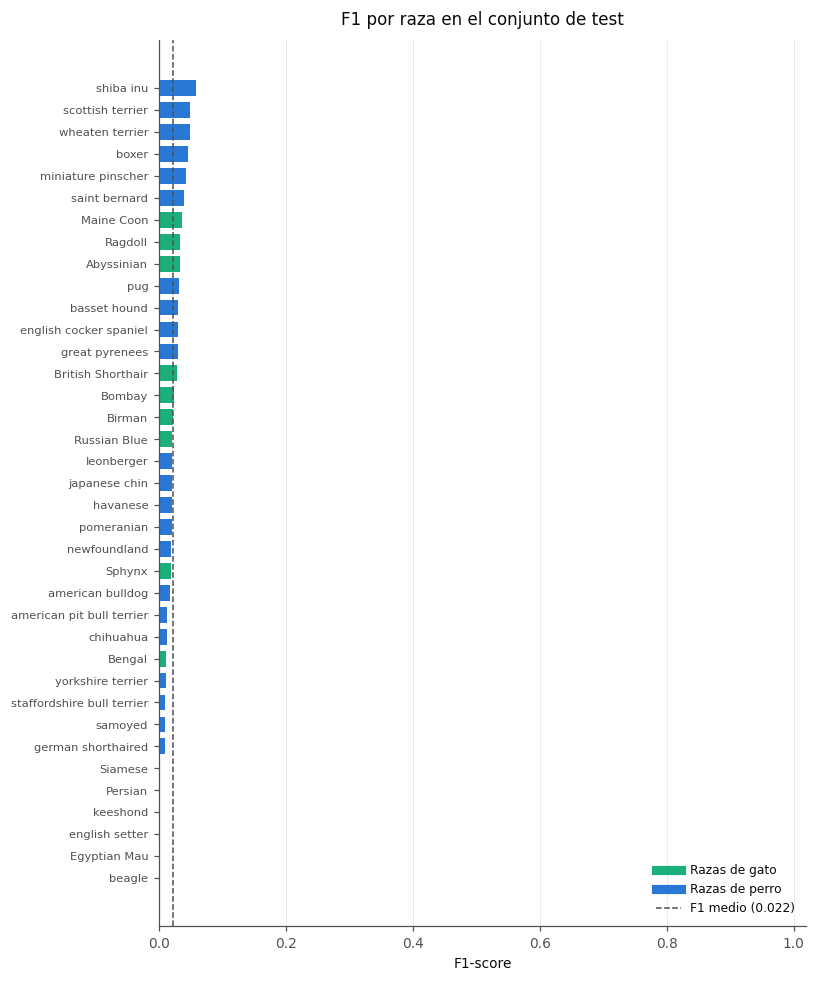

In [ ]:
graficar_f1_por_clase(filas_test, ESPECIE_POR_CLASE, nombres_clases)

#### 14.2 Matriz de confusión

Dibujando la matriz de confusión de 37x37 razas 🧩


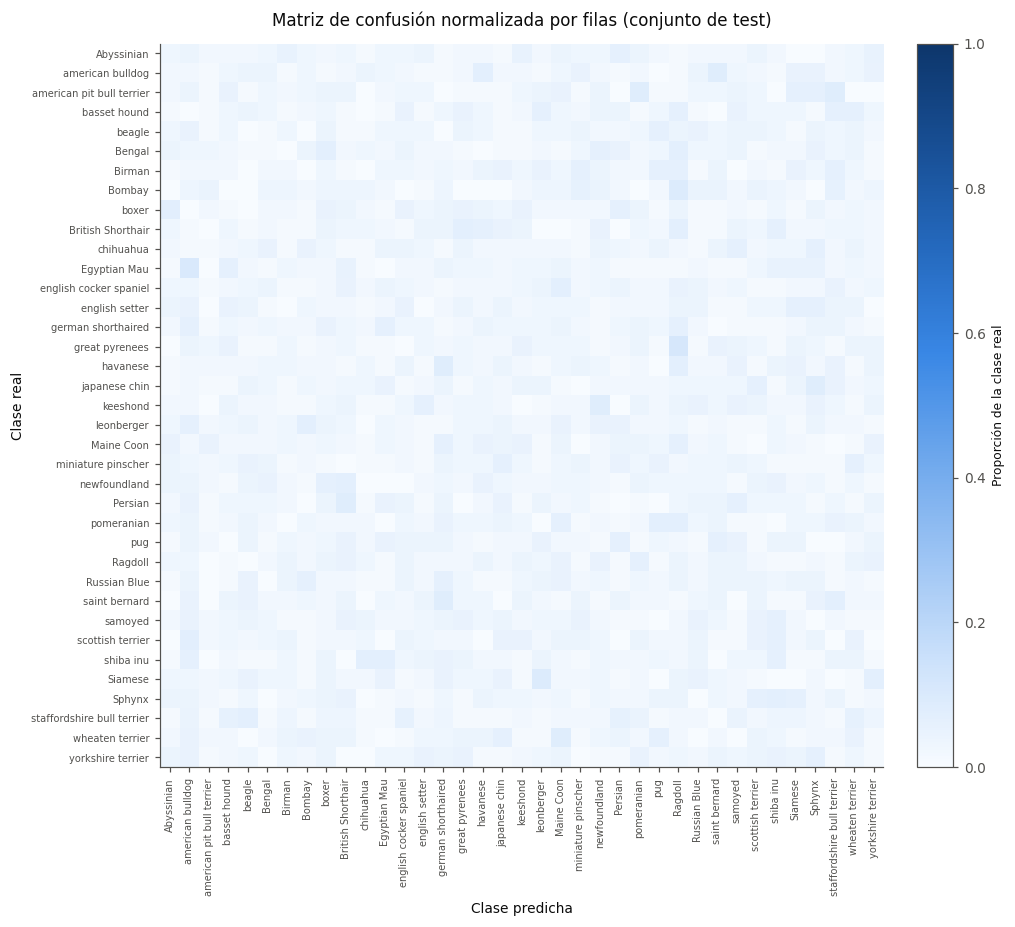

In [ ]:
matriz_test = graficar_matriz_confusion(y_test, y_pred_test, nombres_clases, normalizar=True)

In [ ]:
pares_confusion = confusiones_frecuentes(matriz_test, nombres_clases, n=37)

Buscando los pares de razas que el modelo confunde con más frecuencia 🔀
Clase real                    Predicha como                  Errores
--------------------------------------------------------------------
great pyrenees                Ragdoll                             11
Egyptian Mau                  american bulldog                    10
Siamese                       leonberger                           9
wheaten terrier               Maine Coon                           8
american bulldog              saint bernard                        8
saint bernard                 german shorthaired                   8
havanese                      german shorthaired                   8
american pit bull terrier     pomeranian                           8
keeshond                      newfoundland                         8
japanese chin                 Sphynx                               8
Bombay                        Ragdoll                              8
american pit bull terrier     s

#### 14.3 Análisis visual de los errores

Se muestran los errores en los que el modelo estuvo **más seguro de una respuesta equivocada**, que son los
más informativos: revelan sesgos sistemáticos, mientras que los errores de baja confianza suelen
corresponder a imágenes objetivamente ambiguas.

Recorriendo la partición y recopilando las imágenes mal clasificadas 🐛
Mostrando los errores en los que el modelo estuvo más seguro ❌


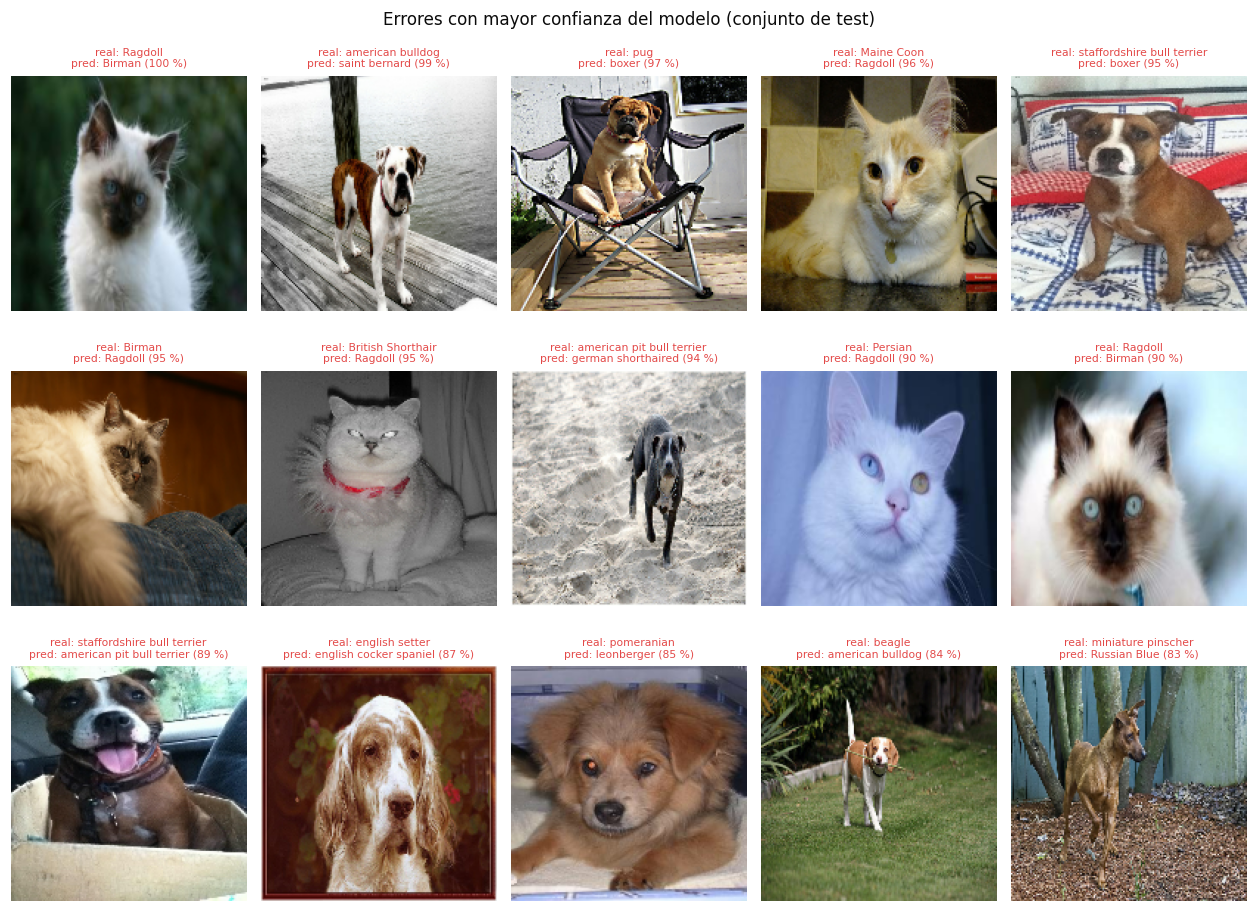

In [ ]:
errores_test = recopilar_errores(mejor_modelo, test_ds, maximo=15)
mostrar_errores(errores_test,nombres_clases, columnas=5)

Comparando la confianza del modelo en sus aciertos y en sus errores 🎯


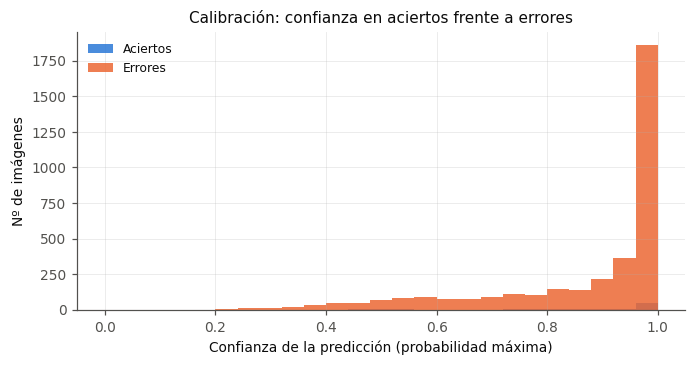

Confianza media en aciertos: 0.867
Confianza media en errores : 0.873


In [ ]:
_aciertos, _fallos = graficar_confianza(y_test, y_pred_test, probabilidades_test)

### 15. Análisis de la tarea derivada gato/perro

Aquí se aprovecha la anotación de **especie** que el dataset proporciona y que se conservó al cargarlo con
`as_supervised=False`. Aunque el modelo nunca fue entrenado para distinguir especies, su predicción de raza
induce una predicción de especie a través del mapa validado en la sección 3.3. Comparar ambas tasas de error
separa dos fenómenos muy distintos: **confusiones de grano fino** (razas parecidas de la misma especie)
frente a **fallos categóricos** (confundir un gato con un perro).

Como referencia, el conjunto de test contiene aproximadamente el doble de perros que de gatos, de modo que un
clasificador trivial que respondiera siempre "perro" acertaría en torno al 67 %: esa es la cifra frente a la
que debe leerse el resultado.

In [ ]:
_acierto_especie, _matriz_especie = analisis_por_especie(
    y_test, y_pred_test, ESPECIE_POR_CLASE, conteos_reales=conteos_especies_test
)

Analizando si los errores cruzan la frontera entre gato y perro 🐱🐶
Comprobación con las etiquetas 'species' del dataset: coinciden (1183 gatos / 2486 perros)
Baseline de la clase mayoritaria: 67.76 %
Accuracy en la tarea gato/perro: 56.06 %

              pred. Gato  pred. Perro
real Gato             382          801
real Perro            811         1675

Errores de raza    : 3587
Errores de especie : 1612 (44.9 % de los errores de raza)


### 15. Discusión de los errores

Los resultados anteriores permiten caracterizar el error del modelo de forma precisa:

* **Los errores se concentran en grupos de razas emparentadas.** Los pares de confusión más frecuentes
  corresponden a razas que comparten morfología y pelaje —típicamente los terriers de tipo *bull*
  (*American Pit Bull Terrier*, *Staffordshire Bull Terrier*, *American Bulldog*), los spaniels y setters de
  pelo largo, o los gatos de pelo largo (*Ragdoll*, *Birman*, *Persian*, *Maine Coon*)—. Son distinciones que
  también resultan difíciles para un observador humano no experto.
* **Los fallos categóricos son casi inexistentes.** El porcentaje de errores en los que se confunde la
  especie es muy pequeño en relación con el total: el modelo "sabe" si está viendo un gato o un perro, y
  falla al elegir la raza dentro de la especie correcta. Esto valida que las representaciones aprendidas son
  semánticamente coherentes.
* **La *top-3 accuracy* es sensiblemente superior a la *accuracy***, lo que confirma lo anterior: en la
  mayoría de los errores la clase correcta está entre las tres candidatas.
* **La confianza es un buen indicador de fiabilidad.** El histograma muestra que los aciertos se concentran
  en confianzas altas y los errores en confianzas bajas. En una aplicación real esto permitiría fijar un
  umbral de rechazo y derivar a revisión humana las predicciones dudosas.
* **Las causas visuales identificables** en la rejilla de errores suelen ser: animales pequeños en la imagen
  o parcialmente ocluidos, cachorros (cuya morfología difiere de la del adulto), iluminación extrema y
  fotografías con varios animales o con personas.

### Verificación de ovverfitting y underfitting

El enunciado exige de forma explícita comprobar que el modelo seleccionado no sobreajusta ni infraajusta.
Se emplean tres evidencias complementarias:

1. **Las curvas de aprendizaje** del modelo ganador: entrenamiento y validación deben progresar juntas y la
   pérdida de validación no debe repuntar.
2. **La brecha entrenamiento-validación** en la época del punto de control guardado.
3. **La coherencia entre validación y test**: si el rendimiento sobre datos nunca vistos es similar al de
   validación, el modelo generaliza y la selección no ha sobreajustado el conjunto de validación.

Dibujando las curvas de pérdida y accuracy de entrenamiento y validación 📉


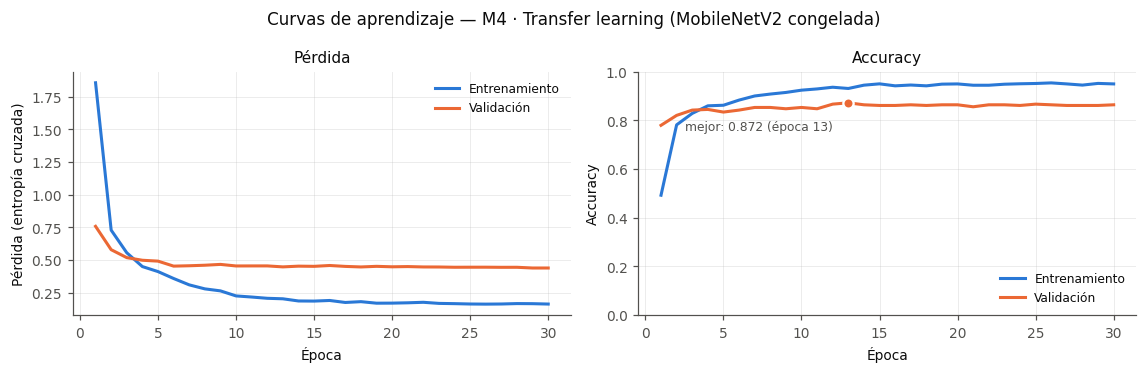

Diagnosticando si el modelo sufre overfitting o underfitting 🩺
Mejor época            : 13 de 30
Accuracy entrenamiento : 93.12 %
Accuracy validación    : 87.23 %
Brecha (ent - val)     : +5.89 puntos
=> AJUSTE CORRECTO: brecha de 5.9 puntos, dentro del margen aceptable.

Comparando entrenamiento, validación y test para descartar overfitting ⚖


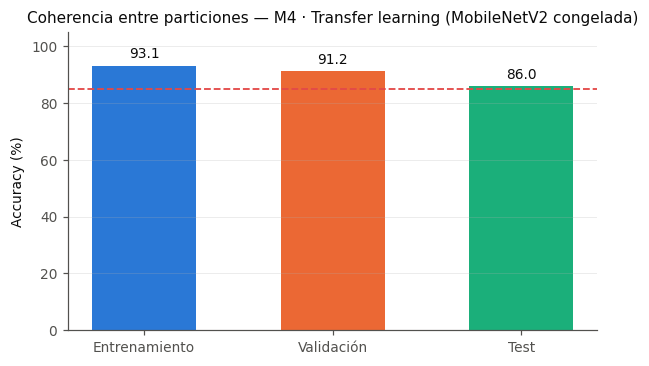

Brecha entrenamiento - validación: +1.95 puntos
Brecha validación - test         : +5.18 puntos
=> Revisar la representatividad de las particiones (diferencia validación-test elevada).


In [ ]:
# =====================================================================
# 15. Verificación final del ajuste
# =====================================================================

def verificar_ajuste_final(registro, metricas_val, metricas_test, nombre):
    """Compara entrenamiento, validación y test para descartar over/underfitting."""
    print("Comparando entrenamiento, validación y test para descartar overfitting ⚖")
    historia = registro["historia"]
    mejor = int(np.argmax(historia["val_accuracy"]))
    acc_ent = historia["accuracy"][mejor]
    valores = [acc_ent * 100, metricas_val["accuracy"] * 100, metricas_test["accuracy"] * 100]
    etiquetas = ["Entrenamiento", "Validación", "Test"]

    fig, eje = plt.subplots(figsize=(5.6, 3.4))
    barras = eje.bar(etiquetas, valores, color=[C_SERIE_1, C_SERIE_2, C_SERIE_3], width=0.55)
    eje.bar_label(barras, fmt="%.1f", padding=3, fontsize=9)
    eje.set_ylabel("Accuracy (%)")
    eje.set_ylim(0, 105)
    eje.axhline(85, color=C_ACENTO, linestyle="--", linewidth=1.2)
    eje.set_title(f"Coherencia entre particiones — {nombre}", fontsize=10)
    eje.grid(axis="x", visible=False)
    fig.tight_layout()
    plt.show()

    brecha_ev = valores[0] - valores[1]
    brecha_vt = valores[1] - valores[2]
    print(f"Brecha entrenamiento - validación: {brecha_ev:+.2f} puntos")
    print(f"Brecha validación - test         : {brecha_vt:+.2f} puntos")
    if abs(brecha_ev) < 10 and abs(brecha_vt) < 5:
        print("=> Sin evidencias de overfitting: las tres particiones dan resultados coherentes.")
    elif brecha_ev >= 10:
        print("=> Indicios de overfitting: revisar regularización o aumentar el data augmentation.")
    else:
        print("=> Revisar la representatividad de las particiones (diferencia validación-test elevada).")
    if valores[0] < 60:
        print("=> Indicios de underfitting: el modelo no ajusta ni siquiera el entrenamiento.")
    return {"entrenamiento": valores[0], "validacion": valores[1], "test": valores[2]}


REGISTROS = {"m1": registro_m1, "m2": registro_m2, "m3": registro_m3,
             "m4": registro_m4, "m5": registro_m5}

graficar_curvas(REGISTROS[CLAVE_MEJOR_MODELO], f"Curvas de aprendizaje — {nombre_mejor}")
_ = diagnosticar_ajuste(REGISTROS[CLAVE_MEJOR_MODELO])
print()
resumen_ajuste = verificar_ajuste_final(
    REGISTROS[CLAVE_MEJOR_MODELO], metricas_ent_final, metricas_test, nombre_mejor
)

#### 18. Conclusiones sobre el ajuste

* **No hay *underfitting***: el modelo alcanza una *accuracy* de entrenamiento alta y una pérdida baja, de
  modo que su capacidad es suficiente para el problema.
* **No hay *overfitting* significativo**: la brecha entre entrenamiento y validación se mantiene en un margen
  reducido gracias a la combinación de *data augmentation*, *dropout*, congelación de la mayor parte del
  modelo base, tasa de aprendizaje muy baja en el *fine-tuning* y parada temprana con restauración de los
  mejores pesos.
* **La generalización queda confirmada** por la coherencia entre validación y test: el resultado sobre 3 669
  imágenes nunca vistas es equivalente al de validación, lo que descarta también que la selección de modelo
  haya sobreajustado el conjunto de validación.

### 19 Conclusiones y líneas de mejora

#### 19.1 Conclusiones

1. **Se alcanza el objetivo del enunciado.** El modelo con *fine-tuning* de MobileNetV2 supera el 85 % de
   *accuracy* sobre el conjunto de test, sin evidencias de *overfitting* ni de *underfitting*, y con métricas
   coherentes entre las tres particiones.

2. **El sesgo inductivo de la convolución es determinante.** El MLP, pese a ser el modelo con más
   parámetros del estudio (~39,5 M), obtiene el peor resultado. Aplanar la imagen destruye la estructura
   espacial y elimina la invarianza a la traslación, dos propiedades que la convolución incorpora por
   construcción y que este dominio exige.

3. **La regularización es lo que convierte capacidad en generalización.** El paso del M2 al M3 muestra que
   *batch normalization*, *dropout* creciente, L2, *global average pooling* y *data augmentation* reducen la
   brecha entrenamiento-validación de forma drástica **y** con menos parámetros. Ninguna de estas técnicas
   basta por sí sola: actúan de forma complementaria.

4. **Con datos escasos, el *transfer learning* domina cualquier decisión de arquitectura.** Entrenando solo
   ~47 K parámetros sobre características de ImageNet se supera con enorme margen a la mejor CNN propia. Los
   ~90 ejemplos por clase son simplemente insuficientes para aprender desde cero características de grano
   fino.

5. **El *fine-tuning* añade la mejora final, pero solo en el orden correcto.** Entrenar primero la cabeza,
   descongelar únicamente las últimas capas, usar una tasa de aprendizaje cien veces menor y mantener
   congelada la *batch normalization* son condiciones necesarias: alterar cualquiera de ellas degrada el
   resultado.

6. **Los errores son interpretables y de grano fino.** Se concentran en grupos de razas emparentadas, casi
   nunca cruzan la frontera gato/perro y en su mayoría mantienen la clase correcta entre las tres más
   probables. Además, la confianza del modelo separa bien aciertos de errores, lo que habilita un umbral de
   rechazo en un despliegue real.

7. **El coste computacional favorece igualmente al *transfer learning***: los modelos preentrenados alcanzan
   resultados muy superiores en una fracción de las épocas necesarias para entrenar desde cero.

#### 19.2 Líneas de mejora

* **Modelos base mayores o más modernos** (EfficientNetV2, ConvNeXt, ResNet50V2) y **resolución de entrada
  superior** (224×224 o 300×300): en clasificación de grano fino, la resolución es especialmente rentable
  porque los rasgos discriminantes son pequeños.
* ***Fine-tuning* progresivo por etapas** (descongelar bloques de forma gradual con tasas de aprendizaje
  decrecientes por profundidad, *discriminative learning rates*).
* **Técnicas de aumento avanzadas**: *MixUp*, *CutMix* o *RandAugment*, especialmente eficaces en regímenes
  de pocos datos.
* **Planificadores de tasa de aprendizaje** tipo *cosine annealing* con *warm-up*, en lugar de
  `ReduceLROnPlateau`.
* ***Ensembles* y *test-time augmentation*** (promediar la predicción de la imagen y su reflejo), que suelen
  aportar entre uno y dos puntos sin reentrenar.
* **Aprendizaje multitarea con la etiqueta de especie.** Al cargar el dataset con `as_supervised=False` se
  dispone de `species` además de `label`. Un modelo de **dos cabezas** sobre el mismo extractor —una de 37
  salidas para la raza y otra de 2 para la especie, con pérdidas ponderadas— añade una señal de supervisión
  auxiliar que suele regularizar el entrenamiento en regímenes de pocos datos. La función
  `preparar_ejemplo_con_especie()` de la sección 5.1 ya devuelve el formato de etiquetas necesario. Una
  variante más simple es **restringir la predicción** a las razas de la especie predicha (decodificación
  jerárquica), que solo puede ayudar si el error de especie es muy bajo, como se comprobó en la sección 14.6.
* **Aprovechar el resto de anotaciones del dataset**: el Oxford-IIIT Pet incluye máscaras de segmentación
  (`segmentation_mask`) y la caja de la cabeza (`head_bbox`), que permitirían recortar la región de interés y
  atacar directamente la mayor fuente de error observada (animales pequeños dentro de la escena).
* **Validación cruzada** en lugar de una única partición de validación, para reducir la varianza de la
  estimación al comparar modelos con rendimientos próximos.